## Import libraries

In [390]:
%pwd

'/home/dliu64/Dongyi-Oral-Qual/notebooks'

In [23]:
%pip install uproot3_methods

Note: you may need to restart the kernel to use updated packages.


In [24]:
from pathlib import Path
import numpy as np
import numba as nb
import hist.dask as had
from matplotlib import pyplot as plt
import awkward as ak
import dask
from hist.dask import Hist
from coffea.nanoevents import NanoEventsFactory, PHYSLITESchema, BaseSchema
from coffea.analysis_tools import PackedSelection
import mplhep
import uproot
import coffea.nanoevents
from tqdm import tqdm_notebook
import vector
#import uproot3_methods.base
#from uproot3_methods.base import *
import mplhep as hep
import matplotlib as mpl
mpl.rcParams['font.family'] = ['serif']
hep.style.use([hep.style.ATLAS])
fm = mpl.font_manager
fm.get_font_names()

PHYSLITESchema.warn_missing_crossrefs = False

In [3]:
from importlib.metadata import version

for package in ["numpy", "awkward", "uproot", "coffea", "dask", "matplotlib", "scipy"]:
    print(f"# {package}: v{version(package)}")

# numpy: v1.26.4
# awkward: v2.7.4
# uproot: v5.5.2
# coffea: v2025.1.1
# dask: v2024.12.1
# matplotlib: v3.10.1
# scipy: v1.15.2


## Set up parameters

#### TTree's Branches

In [25]:
file_path = "/home/dliu64/Higgs/evttree-mc23_13p6TeV.601600.PhPy8_PDF4LHC21_ggH125_kt200_MiNLO_bb.merge.DAOD_PHYS.e8472_e8455_s3873_s3874_r14622_p6491.root"

file_path=f"{file_path}{':evttree'}"
#file_path=f"{weight_VBF_path}{':weitree'}"


sample_file = uproot.open(file_path)
sample_file.keys()

['runNumber',
 'eventNumber',
 'lumiBlock',
 'averagePU',
 'eventPU',
 'mcFlag',
 'mcProcess',
 'jetCalConf',
 'fatJetCalConf',
 'HLT_iso_mu50',
 'HLT_noniso_mu50',
 'HLT_j360_a10_lcw_sub_L1J100',
 'HLT_j420_a10_lcw_L1J100',
 'HLT_j440_a10t_lcw_jes_L1J100',
 'HLT_j390_a10t_lcw_jes_30smcINF_L1J100',
 'HLT_j460_a10t_lcw_jes_L1J100',
 'HLT_j420_a10t_lcw_jes_35smcINF_L1J100',
 'HLT_j420_a10t_lcw_jes_35smcINF_L1SC111',
 'HLT_j420_L1J100',
 'HLT_j460_L1J100',
 'HLT_j480_L1J100',
 'HLT_j460_a10r_L1J100',
 'HLT_j460_a10r_L1SC111_CJ15',
 'HLT_j360_a10t_lcw_jes_L1J100',
 'HLT_j420_a10t_lcw_jes_L1J100',
 'HLT_j460_a10t_lcw_jes_L1J100',
 'HLT_j480_a10t_lcw_jes_L1J100',
 'HLT_j460_a10_lcw_subjes_L1J100',
 'HLT_j420_35smcINF_a10t_lcw_jes_L1J100',
 'HLT_j420_35smcINF_a10t_lcw_jes_L1SC111_CJ15',
 'HLT_j360_a10sd_cssk_pf_jes_ftf_preselj225_L1J100',
 'HLT_j360_a10sd_cssk_pf_jes_ftf_preselj225_L1SC111_CJ15',
 'HLT_j420_35smcINF_a10sd_cssk_pf_jes_ftf_preselj225_L1J100',
 'HLT_j460_a10sd_cssk_pf_jes_ftf_pr

#### File paths

In [26]:
# ggF
ggF_path = "/home/dliu64/Higgs/evttree-mc23_13p6TeV.601600.PhPy8_PDF4LHC21_ggH125_kt200_MiNLO_bb.merge.DAOD_PHYS.e8472_e8455_s3873_s3874_r14622_p6491.root"
weight_ggF_path = "/home/dliu64/Higgs/weitree-mc23_13p6TeV.601600.PhPy8_PDF4LHC21_ggH125_kt200_MiNLO_bb.merge.DAOD_PHYS.e8472_e8455_s3873_s3874_r14622_p6491.root"

# VBF
VBF_path = "/home/dliu64/Higgs/evttree-mc23_13p6TeV.601597.PhPy8EG_PDF4LHC21_VBFH125_bb.DAOD_PHYS.e8532_e8528_s4162_s4114_r14622_r14663_p6491.root"
weight_VBF_path = "/home/dliu64/Higgs/weitree-mc23_13p6TeV.601597.PhPy8EG_PDF4LHC21_VBFH125_bb.DAOD_PHYS.e8532_e8528_s4162_s4114_r14622_r14663_p6491.root"


#file_path=f"{file_path}{':evttree'}"

sample_file = uproot.open(VBF_path)
print(sample_file.keys())
with uproot.open(VBF_path, handler=uproot.MemmapSource) as file:
    dataset = file["evttree"].arrays()

['evttree;2', 'evttree;1']


In [27]:
def filter_name(name):
    return name in [
        'bosonPdgId', 'bosonStatus', 'bosonBarcode',
 'bosonPt', 'bosonPx', 'bosonPy', 'bosonPz', 'bosonE', 'bosonM',
 'bosonChildPdgId', 'bosonChildPt', 'bosonChildPx', 'bosonChildPy', 'bosonChildPz', 'bosonChildE',
 'jetFlavour', 'jetPt', 'jetPx','jetPy','jetPz','jetE','jetM', 
 'fatJetTruthPt','fatJetTruthPx','fatJetTruthPy','fatJetTruthPz','fatJetTruthE','fatJetTruthM',
 'fatJetRawPt','fatJetRawPx','fatJetRawPy','fatJetRawPz','fatJetRawE','fatJetRawM',
 'fatJetPt','fatJetPx','fatJetPy','fatJetPz','fatJetE','fatJetM',
 'fatJetDiVRJetMass', 'fatJetDiVRJetPt',
 'fatJetTruthLabel',
 'fatJetNBHadrons', 'fatJetNCHadrons',
 'fatJetGN2XHbb', 'fatJetGN2XHcc', 'fatJetGN2XTop', 'fatJetGN2XQCD',
 'fatJetGN2Xv01Hbb','fatJetGN2Xv01Hcc', 'fatJetGN2Xv01Top', 'fatJetGN2Xv01QCD',
 'fatJetGN2Xv02Hbb', 'fatJetGN2Xv02Hcc', 'fatJetGN2Xv02Top', 'fatJetGN2Xv02QCD',
 'fatJetGN2XMHbb',
 'fatJetGN2XMHcc',
 'fatJetGN2XMTop',
 'fatJetGN2XMQCD','eventMCWeight', 'eventNumber', 'runNumber', 'MET',
 'vrJetPt','vrJetPx','vrJetPy','vrJetPz','vrJetE','vrJetM',
 'vrJetNTracks','vrJetIdFatJet',
 'vrJetFlavour','vrJetHadronGhostTruthLabelID','vrJetHadronGhostExtendedTruthLabelID',
 'vrJetSV1VtxNTrk','vrJetSV1VtxMass',
 'vrJetDL1r','vrJetDL1d','vrJetGN1','vrJetGN2','vrJetBHadronPdgId',
 'vrJetBHadronBarcode',
 'vrJetBHadronPt','vrJetBHadronPx', 'vrJetBHadronPy', 'vrJetBHadronPz', 'vrJetBHadronE', 'vrJetBHadronM',
 'vrJetBHadronProdVtxX', 'vrJetBHadronProdVtxY', 'vrJetBHadronProdVtxZ', 
 'vrJetBHadronDecVtxX','vrJetBHadronDecVtxY', 'vrJetBHadronDecVtxZ', 'vrJetBCHadronDecVtxX', 'vrJetBCHadronDecVtxY', 'vrJetBCHadronDecVtxZ',
    ]

In [28]:
prepend_path = "/home/dliu64/Higgs/"
samples = [
    "evttree-mc23_13p6TeV.601600.PhPy8_PDF4LHC21_ggH125_kt200_MiNLO_bb.merge.DAOD_PHYS.e8472_e8455_s3873_s3874_r14622_p6491.root", # ggF
    "evttree-mc23_13p6TeV.601597.PhPy8EG_PDF4LHC21_VBFH125_bb.DAOD_PHYS.e8532_e8528_s4162_s4114_r14622_r14663_p6491.root", # VBF
    "evttree-mc23_13p6TeV.604224.PhPy8EG_PDF4LHC21_allHad_ttH125_HTop.DAOD_PHYS.e8579_e8528_s4162_s4114_r15540_r15516_p6491.root", # ttH
    "evttree-mc23_13p6TeV.601237.PhPy8EG_A14_ttbar_hdamp258p75_allhad.deriv.DAOD_PHYS.e8514_e8528_s4162_s4114_r15540_r15516_p6491.root", # ttbar_all_hadron
    "evttree-mc23_13p6TeV.601229.PhPy8EG_A14_ttbar_hdamp258p75_SingleLep.deriv.DAOD_PHYS.e8514_e8528_s4162_s4114_r15540_r15516_p6491.root", # ttbar_single_lepton
    "evttree-mc23_13p6TeV.801169.Py8EG_A14NNPDF23LO_jj_JZ4.deriv.DAOD_PHYS.e8514_e8528_s4162_s4114_r14622_r14663_p6491.root" # QCD
]

events_list = [
    NanoEventsFactory.from_root(
        {prepend_path + sample: "evttree"},
        delayed=True,
        schemaclass=BaseSchema,
        uproot_options={"filter_name": filter_name}
    ).events()
    for sample in samples
]

VBF_events = NanoEventsFactory.from_root(
        {prepend_path + samples[1]: "evttree"},
        delayed=True,
        schemaclass=BaseSchema,
        uproot_options={"filter_name": filter_name}
    ).events()

ggF_events = NanoEventsFactory.from_root(
        {prepend_path + samples[0]: "evttree"},
        delayed=True,
        schemaclass=BaseSchema,
        uproot_options={"filter_name": filter_name}
    ).events()


# Understanding HbbISRRecoilAnalysis.C

## Setup initial parameters
- instante lumi=10fb-1
- 30<Higgs Mass<210
- 0<eta<2
## Make historgrams
- hSRLMass/hSRLPt: histogram of small-r leading jet's mass and pT
- hSRSMass/hSRSPt: histogram of small-r subleading jet's mass and pT
- hRecoilMass/hRecoilPt: histogram of recoiling jet mass and pT

## CMS selections
- The size of fatjet is at least one
- leading fatjet pT > 500, eta < 2.5
- The size of thin jets is at least two
- jets pT > 30, dR(J, j)>0.8
- eta(j, j), m_jj, dR(j, j)

#### playground

In [29]:
xSec = [.27386, 4.2207]
kFactor = [1, 1]
filterEff = [1, 1]
intLumi = 10 # fb^-1

ggF_events = events_list[0]
VBF_events = events_list[1]


ip = 0

VBF_weights = VBF_events.eventMCWeight.compute()
ggF_weights = ggF_events.eventMCWeight.compute()

sumOfWeightMC = [2.26e+05, 2.11e+06]
eventmc = [.54, 4.25]

wei = xSec[ip] * kFactor[ip] * filterEff[ip] * intLumi * 1000. * eventmc[ip]/(sumOfWeightMC[ip])
print(wei)

0.006543557522123894


In [39]:
VBF_bosonpt = VBF_events.bosonPt.compute()
VBF_bosone = VBF_events.bosonE.compute()
VBF_bosonpx = VBF_events.bosonPx.compute()
VBF_fatjetNB= VBF_events.fatJetNBHadrons.compute()
VBF_fatjetTruthM = VBF_events.fatJetTruthM.compute()
VBF_fatjetM = VBF_events.fatJetM.compute()
VBF_fatjetPt = VBF_events.fatJetPt.compute()


VBF_bosonid = VBF_events.bosonPdgId.compute()

print((VBF_bosonpt[:, 0]-VBF_bosonpt[:, 1]))
print(VBF_bosone[:5])
print(VBF_bosonpx[:5])
print(VBF_bosonid[:5])
#print(VBF_fatjetpt0[:3])
#print(VBF_jetpt[:3])
print(VBF_events.fatJetNBHadrons.compute())


[0.369, -0.398, 0.232, 0.294, 0.0522, ..., 0.127, 0.188, -1.56, -0.078, 1.55]
[[283, 283], [396, 396], [386, 385], [418, 417], [306, 306]]
[[-243, -242], [187, 187], [-198, -197], [233, 233], [256, 256]]
[[25, 25], [25, 25], [25, 25], [25, 25], [25, 25]]
[[2, 0], [1], [1], [0, 1], [1], [0], [], ..., [1], [], [], [], [1, 0], [1], [1]]


In [40]:
o = (VBF_fatjetNB ==2)
VBF_fatjetM[ak.num(VBF_fatjetM[o])>0]
VBF_fatjetPt[ak.num(VBF_fatjetPt[o])>0]
#VBF_fatjetTruthM[ak.num(VBF_fatjetTruthM[o])>0]

<Array [[247, 226], [...], ..., [343, 204]] type='9652 * [var * float32[par...'>

In [126]:
jetpt0

<Array [[229, 143, 132, 48.1], ..., [329, ...]] type='30326 * [var * float3...'>

#### Marco's cutflow
[ATLAS Internal note](https://cds.cern.ch/record/2703097/files/ATL-COM-PHYS-2019-1425.pdf)
- ggF
    - total number of events: 362160
    - fatjet size >= 1 cut: 300217;
    - firstselection cut (any fatjet that satisfies pT > 450, M > 60): 13619;
    - fatjet size >= 2 cut: 13619;
    - subleading fatjet pT > 350 & eta < 2.0 cut: 10839;
    - 450 < fatjetpT < 1500 & bosonpT > 50 cut: leading jet # 10803, subleading jet # 6384;
    - (# of SRL: 4600, # of SRS 2480, # of Recoil jet 10107)

#### Initial parameters

In [30]:
import hist
from hist import Hist
import hist.dask as had

category = ["ggF", "VBF"]

max_eta = 2
min_FJPt = 450
max_FJPt = 1500
min_FJM = 60
max_FJM = 210
massGeVPerBin = 5
pTGeVPerBin = 50
num_mass_bins = int((max_FJM-30)/massGeVPerBin)
num_pT_bins = int((max_FJPt-min_FJPt)/pTGeVPerBin)

xSec = [.27386, 4.2207, .255]
kFactor = [1, 1, 1]
filterEff = [1, 1, 1]
intLumi = 10 # fb^-1

sumOfWeightMC = [2.25913e+05, 2.10764e+06, 546361]
eventmc = [.54, 4.25, 1]
sumOfWeightEvent = [196409, 127531, 138077]
theory_weights = [.00657588, .0842073, 0.00116801]


hist_list = {
    'SRL_m': Hist.new.StrCat(category, name='cat')
            .Regular(num_mass_bins, 30, max_FJM, name='Signal Leading Fatjet mass').Weight(), 
    'SRL_pt': Hist.new.StrCat(category, name='cat')
            .Regular(num_pT_bins, min_FJPt, max_FJPt, name='Signal Leading Fatjet pT').Weight(),
    'SRS_m': Hist.new.StrCat(category, name='cat')
            .Regular(num_mass_bins, 30, max_FJM, name='Signal Subleading Fatjet mass').Weight(),
    'SRS_pt': Hist.new.StrCat(category, name='cat')
            .Regular(num_pT_bins, min_FJPt, max_FJPt, name='Signal Subleading Fatjet pT').Weight(),
    'Recoil_m': Hist.new.StrCat(category, name='cat')
            .Regular(num_mass_bins, 30, max_FJM, overflow=True, underflow=True, name='Recoil Fatjet mass').Weight(),
    'Recoil_pt': Hist.new.StrCat(category, name='cat')
            .Regular(num_pT_bins, min_FJPt, max_FJPt, name='Recoil Fatjet pT').Weight() #'''
}



#### Scripts

In [10]:
%%time
ip = 0
events = events_list[ip] 
total_number = ak.num(events.fatJetPx, axis=0).compute()

selection1 = PackedSelection()
fatjet_size_cut = ak.num(events.fatJetPt)>=1 # at least have one fajet
boson_size_cut = ak.num(events.bosonPt)>=1 # there's must be at least one boson
fatjet_pt_m =  ak.any((events.fatJetPt>450) & (events.fatJetM>60), axis=1) # leading fatjet pT>450 and M>60
combine = (ak.num(events.fatJetPt)>=2) & fatjet_pt_m # at least have two fatjets

subleading_cut = ak.sum(events.fatJetPt>350, axis=-1)>=2 # subleading fatjet pT>350
combine1 = combine & subleading_cut
combine2 = combine1 & boson_size_cut


cuts = [fatjet_size_cut, fatjet_pt_m, combine, subleading_cut, combine1, combine2]
selection1.add('fatjet_size_cut', fatjet_size_cut)
selection1.add('fatjet_pt_m', fatjet_pt_m)
selection1.add('combine', combine)
selection1.add('subleading cut', subleading_cut)
selection1.add('combine1', combine1)
selection1.add('combine2', combine2)


results = []
print('total number', total_number)
for cut, cut_name in zip(cuts[:], selection1.names[:]):
    n_events = ak.sum(selection1.all(cut_name), axis=0)
    results.append(n_events)
cut_results, *_ = dask.compute(results)
for cut, n_events in zip(selection1.names, cut_results):
    print(f"Events passing '{cut}': {n_events}")

total number 362160
Events passing 'fatjet_size_cut': 300217
Events passing 'fatjet_pt_m': 14688
Events passing 'combine': 13619
Events passing 'subleading cut': 22412
Events passing 'combine1': 10839
Events passing 'combine2': 10839
CPU times: user 485 ms, sys: 81.5 ms, total: 566 ms
Wall time: 798 ms


In [154]:
o = (fatjetpt < 1500) & (fatjetpt > 450)
away = dR >= 0.30
notNB = NB != 2
w = o & (away | notNB)
o

<Array [[True, True], ..., [True, False]] type='10804 * [var * bool[paramet...'>

In [96]:
%%time
from coffea.nanoevents.methods import vector

cut = selection1.all('combine2') & (ak.fill_none(ak.firsts(events.bosonPt[events.bosonPdgId.compute()==25]), 0)>50)
# ak.firsts will fill in the blank with none
# ak.fill_none(array, 0) fill the none with 0

fatjetpt = events.fatJetPt[cut].compute()
fatjetm = events.fatJetM[cut].compute()
bosonpt = events.bosonPt[cut].compute()
eventmcweight = events.eventMCWeight[cut].compute()
eventnumber = events.eventNumber[cut].compute()
NB = events.fatJetNBHadrons[cut].compute()


boson_vec4 = ak.zip(
        {
            "x": events.bosonPx[cut],
            "y": events.bosonPy[cut],
            "z": events.bosonPz[cut],
            "t": events.bosonE[cut],
        },
        with_name="LorentzVector",
        behavior=vector.behavior,
    )

jet_vec4 = ak.zip(
        {
            "x": events.jetPx[cut],
            "y": events.jetPy[cut],
            "z": events.jetPz[cut],
            "t": events.jetE[cut],
        },
        with_name="LorentzVector",
        behavior=vector.behavior,
    )

fatjet_vec4 = ak.zip(
        {
            "x": events.fatJetPx[cut],
            "y": events.fatJetPy[cut],
            "z": events.fatJetPz[cut],
            "t": events.fatJetE[cut],
        },
        with_name="LorentzVector",
        behavior=vector.behavior,
    )

Leading_cut = (fatjetpt[:,0]>450) & (fatjetpt[:,0]<1500)
Subleading_cut = (fatjetpt[:,1]>350) & (fatjetpt[:,1]<1500)


fatjetpt_leading = fatjetpt[Leading_cut]
fatjetm_leading = fatjetm[Leading_cut]
eventmcweight_leading = eventmcweight[Leading_cut]
fatjetpt_sub = fatjetpt[Subleading_cut]
fatjetm_sub = fatjetm[Subleading_cut]
eventmcweight_sub = eventmcweight[Subleading_cut]

dR = boson_vec4[:,0].delta_r(fatjet_vec4)

dR_L = dR[Leading_cut]
NB_L = NB[Leading_cut]
NB_L_cuts = (NB_L[:,0] == 2) & (dR_L[:,0].compute() < .3)
SRLpt = fatjetpt_leading[NB_L_cuts]
SRLwei = eventmcweight_leading[NB_L_cuts]
SRLm = fatjetm_leading[NB_L_cuts]
Recoil_L_cuts = (dR_L.compute() < .3) & (NB_L == 2)
Recoil_L_pt = fatjetpt_leading[Recoil_L_cuts[:, 0] == False]
Recoil_L_m = fatjetm_leading[Recoil_L_cuts[:, 0] == False]
Recoil_L_wei = eventmcweight_leading[Recoil_L_cuts[:, 0] == False]


dR_S = dR[Subleading_cut]
NB_S = NB[Subleading_cut]
NB_S_cuts = (NB_S[:,1] == 2) & (dR_S[:,1].compute() < .3)
Recoil_S_cuts = (dR_S.compute() < .3) & (NB_S == 2)
SRSm = fatjetm_sub[NB_S_cuts]
SRSwei = eventmcweight_sub[NB_S_cuts]
SRSpt = fatjetpt_sub[NB_S_cuts]
Recoil_S_pt = fatjetpt_sub[Recoil_S_cuts[:, 1]==False]
Recoil_S_m = fatjetm_sub[Recoil_S_cuts[:, 1] == False]
Recoil_S_wei = eventmcweight_sub[Recoil_S_cuts[:, 1] == False]


Recoilpt = ak.flatten([Recoil_L_pt[:,0], Recoil_S_pt[:,1]])
Recoilm = ak.flatten([Recoil_L_m[:,0], Recoil_S_m[:,1]])
Recoilwei = ak.flatten([Recoil_L_wei, Recoil_S_wei])

kinematics = {
    'SRL_m': SRLm[:,0],
    'SRL_pt': SRLpt[:,0],
    'SRL_wei': SRLwei,
    'SRS_m': SRSm[:,1],
    'SRS_pt': SRSpt[:,1],
    'SRS_wei': SRSwei,
    'Recoil_pt': Recoilpt,
    'Recoil_m': Recoilm,
    'Recoil_wei': Recoilwei
}


print(len(fatjetpt_leading), len(fatjetpt_sub), len(SRLpt), len(SRSpt)) # '''

538 538 293 189
CPU times: user 3.26 s, sys: 154 ms, total: 3.41 s
Wall time: 3.63 s


In [97]:
for name, k in hist_list.items():
    h = hist_list[name]
    fill_kwargs = {
        'cat': category[ip],
        h.axes[1].name: kinematics[name],
        'weight': xSec[ip] * kFactor[ip] * filterEff[ip] * intLumi * 1000. * kinematics[name[:name.find('_')+1]+'wei']/(sumOfWeightMC[ip])
    }
    # Fill the histogram
    h.fill(**fill_kwargs)#'''

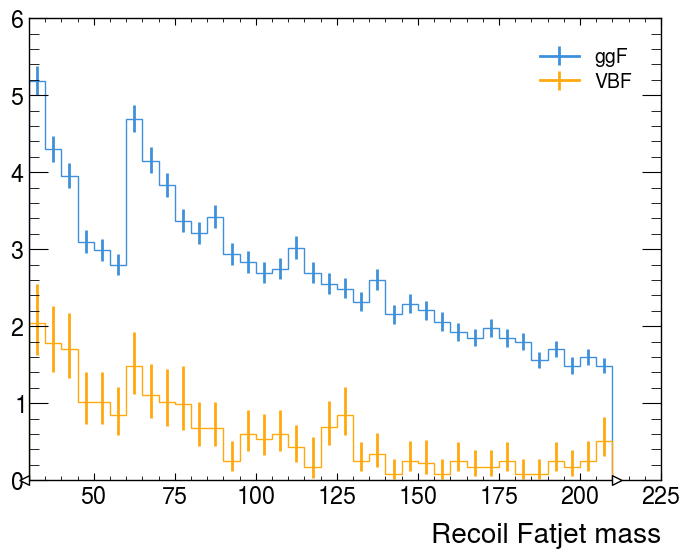

In [112]:
name = 'Recoil_m'

h = hist_list[name]
h.plot()
plt.legend()
plt.ylim(0, None)
plt.xlim(h.to_numpy()[2][0], None)
plt.savefig(f"/home/dliu64/Higgs/plots/{name}.png", dpi=200)

In [18]:
SRL = [fatjet_vec4_2[:,0].eta.compute(), fatjet_vec4_2[:,0].phi.compute()]
Recoil_L=[fatjet_vec4_2[:,1].eta.compute(), fatjet_vec4_2[:,1].phi.compute()]

SRS = [fatjet_vec4_2[:,1].eta.compute(), fatjet_vec4_2[:,1].phi.compute()]
Recoil_S=[fatjet_vec4_2[:,0].eta.compute(), fatjet_vec4_2[:,0].phi.compute()]

NameError: name 'fatjet_vec4_2' is not defined

In [ ]:
for i, ax in enumerate(h.axes):
    print(f"Axis {i}: Name = {ax.name}, Type = {type(ax)}")

##### Playground

In [ ]:
import coffea.processor as processor

class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events, N_bins):
        jet_pt_m = (events.jetPt>30)
        jet_pt_m_cut = ak.any(jet_pt_m, axis=1)
        boson_pt_m_cut = ak.firsts(ak.fill_none(events.bosonPt[events.bosonPdgId==25], 0))>50 # leading boson Pt > 50
        num_cut =  ak.num(events.jetPt)>=2 # >=2 small-R jets
        
        fatjet_size_cut = ak.num(events.fatJetPt)>=1 # at least have 1 fatjet
        fatjet_pt_200_450_m =  (events.fatJetPt<450) & (events.fatJetPt>200) & (events.fatJetM>60)
        fatjet_pt_200_450_m_cut = ak.any(fatjet_pt_200_450_m, axis=1) & fatjet_size_cut & boson_pt_m_cut & num_cut & jet_pt_m_cut
        fatjet_pt_450_1000_m =  (events.fatJetPt<1000) & (events.fatJetPt>450) & (events.fatJetM>60)
        fatjet_pt_450_1000_m_cut = ak.any(fatjet_pt_450_1000_m, axis=1) & fatjet_size_cut & boson_pt_m_cut & num_cut & jet_pt_m_cut
        fatjet_pt_1000_m =  (events.fatJetPt>1000) & (events.fatJetM>60)
        fatjet_pt_1000_m_cut = ak.any(fatjet_pt_1000_m, axis=1) & fatjet_size_cut & boson_pt_m_cut & num_cut & jet_pt_m_cut
        
        
        pt_cuts = {'250<pT<450': fatjet_pt_200_450_m_cut, '450<pT<1000': fatjet_pt_450_1000_m_cut, 'pT>1000': fatjet_pt_1000_m_cut}
        
        h_fatjet_pT = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 200, 1000, name='pT').Double())
        h_jet_pT = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 200, 1000, name='pT').Double())
        h_fatjet_mass = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 0, 200, name='mass').Double())
        h_jet_mass = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 0, 200, name='mass').Double())
        h_fatjet_num = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 0, 10, name='multiplicity').Double())
        h_jet_num = (had.Hist.new.StrCat(list(pt_cuts), name='pt_cut')
            .Regular(N_bins, 0, 10, name='multiplicity').Double())
        
        
        for name, cut in pt_cuts.items():
            h_fatjet_pT = h_fatjet_pT.fill(cut=name, pT=events.fatJetPt[cut])
            h_jet_pT = h_jet_pT.fill(cut=name, pT=ak.flatten(events.jetPt[cut]))
            h_fatjet_mass = h_fatjet_mass.fill(cut=name, mass=ak.flatten(events.fatJetM[cut]))
            h_jet_mass = h_jet_mass.fill(cut=name, mass=ak.flatten(events.jetM[cut]))
            h_fatjet_num = h_fatjet_num.fill(cut=name, multiplicity=ak.num(events.fatJetM[cut], axis=-1))
            h_jet_num = h_jet_num.fill(cut=name, multiplicity=ak.num(events.jetM[cut], axis=-1))
            
        return {
            "entries": ak.num(events, axis=0),
            "fatjet pT": h_fatjet_pT,
            "jet pT": h_jet_pT,
            "fatjet mass": h_fatjet_mass, 
            "jet mass": h_jet_mass, 
            "fatjet num": h_fatjet_num, 
            "jet num": h_jet_num, 
        }
            
    def postprocess(self, accumulator):
        pass

#### CMS cutflow


In [31]:
def calculate_self_values(jet_vec4):
    jets_jets_pair = ak.cartesian([jet_vec4, jet_vec4]).compute()
    jets1 = jets_jets_pair["0"]
    jets2 = jets_jets_pair["1"]
    mask = (jets1.mass < jets2.mass) # Avoid redundacy, we want C^n_n not A^n_n
    deta_jj = abs(jets1.eta[mask]-jets2.eta[mask]) # delta eta between all the jets
    m_jj = (jets1[mask]+jets2[mask]).mass
    dR_jj = jets1[mask].delta_r(jets2[mask])
    return m_jj, dR_jj, deta_jj

In [32]:
from coffea.nanoevents.methods import vector

def generate_mjj_delta_jj(events):

    theory_weights = [.00657588, .0842073, 0.00116801]

    # Build lorentzvector for boson, jet, fatjet
    boson_vec4_0 = ak.zip(
            {
                "x": events.bosonPx[events.bosonPdgId==25],
                "y": events.bosonPy[events.bosonPdgId==25],
                "z": events.bosonPz[events.bosonPdgId==25],
                "t": events.bosonE[events.bosonPdgId==25],
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )

    jet_vec4_0 = ak.zip(
            {
                "x": events.jetPx,
                "y": events.jetPy,
                "z": events.jetPz,
                "t": events.jetE,
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )
    
    vrjet_vec4_0 = ak.zip(
            {
                "x": events.vrJetPx,
                "y": events.vrJetPy,
                "z": events.vrJetPz,
                "t": events.vrJetE,
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )

    fatjet_vec4_0 = ak.zip(
            {
                "x": events.fatJetPx,
                "y": events.fatJetPy,
                "z": events.fatJetPz,
                "t": events.fatJetE,
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )
    
    total_number = ak.num(events.fatJetPx, axis=0).compute()
    
    event_number = events.eventNumber

    
    selection1 = PackedSelection()
    fatjet_size_cut = ak.num(events.fatJetPt)>=1 # at least have 1 fatjet
    fatjet_pt_m =  (events.fatJetPt>200) & (events.fatJetM>60) & (abs(fatjet_vec4_0.eta) < 2.5)
    fatjet_pt_m_cut = ak.any(fatjet_pt_m, axis=1)
    # >=1 large-R jet, pT > 450, m > 60, eta < 2.5

    jet_pt_m = (events.jetPt>30)
    jet_pt_m_cut = ak.any(jet_pt_m, axis=1)
    boson_pt_m_cut = ak.firsts(ak.fill_none(events.bosonPt[events.bosonPdgId==25], 0))>50 # leading boson Pt > 50
    num_cut =  (ak.num(events.fatJetPt)>=1) & (ak.num(events.jetPt)>=2) # >=2 small-R jets
    combine = fatjet_pt_m_cut & num_cut & jet_pt_m_cut
    combine1 =  combine & boson_pt_m_cut

    cuts = [fatjet_size_cut, fatjet_pt_m_cut, combine, jet_pt_m_cut, num_cut, combine, combine1]
    selection1.add('fatjet_size_cut', fatjet_size_cut)
    selection1.add('fatjet_pt_m', fatjet_pt_m_cut)
    selection1.add('jet_pt_m_cut', jet_pt_m_cut)
    selection1.add('boson_pt_m_cut', boson_pt_m_cut)
    selection1.add('num_cut', num_cut)
    selection1.add('combine', combine)
    selection1.add('combine1', combine1)
    
    num_cout_results = []
    wei_event_results = []
    print('total number', total_number, 'weighted events', ak.sum(events.eventMCWeight.compute()))
    for cut, cut_name in zip(cuts[:], selection1.names[:]):
        n_events = ak.sum(selection1.all(cut_name), axis=0)
        wei_events = ak.sum(events.eventMCWeight[selection1.all(cut_name)])
        num_cout_results.append(n_events)
        wei_event_results.append(wei_events)
    cut_results, *_ = dask.compute(num_cout_results)
    cut_wei_results, *_ = dask.compute(wei_event_results)
    #for cut, n_events, wei_events in zip(selection1.names, cut_results, cut_wei_results):
        #print(f"Events passing '{cut}': {n_events}, {wei_events:.1f}")
    
    
    cut = selection1.all('combine1')

    jetpt = events.jetPt[cut]
    jetpx = events.jetPx[cut]
    jetpy = events.jetPy[cut]
    jetpz = events.jetPz[cut]
    jete = events.jetE[cut]
    jetpx = jetpx[abs(jetpt)>30]
    jetpy = jetpy[abs(jetpt)>30]
    jetpz = jetpz[abs(jetpt)>30]
    jete = jete[abs(jetpt)>30]
    
    vrjetpt = events.vrJetPt[cut]
    vrjetpx = events.vrJetPx[cut]
    vrjetpy = events.vrJetPy[cut]
    vrjetpz = events.vrJetPz[cut]
    vrjete = events.vrJetE[cut]
    vrjetpx = vrjetpx[abs(vrjetpt)>30]
    vrjetpy = vrjetpy[abs(vrjetpt)>30]
    vrjetpz = vrjetpz[abs(vrjetpt)>30]
    vrjete = vrjete[abs(vrjetpt)>30]
    
    event_number = event_number[cut]

    eventmcweight = events.eventMCWeight[cut]
    GN2XbbScore = events.fatJetGN2Xv01Hbb[cut]
    boson_vec4 = ak.zip(
            {
                "x": events.bosonPx[cut],
                "y": events.bosonPy[cut],
                "z": events.bosonPz[cut],
                "t": events.bosonE[cut],
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )

    jet_vec4 = ak.zip(
            {
                "x": jetpx,
                "y": jetpy,
                "z": jetpz,
                "t": jete,
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )
    
    vrjet_vec4 = ak.zip(
            {
                "x": vrjetpx,
                "y": vrjetpy,
                "z": vrjetpz,
                "t": vrjete,
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )

    fatjet_vec4 = ak.zip(
            {
                "x": events.fatJetPx[cut],
                "y": events.fatJetPy[cut],
                "z": events.fatJetPz[cut],
                "t": events.fatJetE[cut],
            },
            with_name="LorentzVector",
            behavior=vector.behavior,
        )
    
    jets_bosons_pair = ak.cartesian([jet_vec4, boson_vec4[:,0]]).compute()
    jets = jets_bosons_pair["0"]
    bosons = jets_bosons_pair["1"]
    dR_Bj = jets.delta_r(bosons)

    jets_fatjets_pair = ak.cartesian([jet_vec4, fatjet_vec4]).compute()
    jets = jets_fatjets_pair["0"]
    fatjets = jets_fatjets_pair["1"]
    dR_Jj = jets.delta_r(fatjets)

    #jet_pt_0 = jet_vec4.pt.compute()
    #jet_cut = dR_Bj > 1.3 # Make sure VBF jets are far away from Higgs
    #jet_vec4 = jet_vec4[jet_cut]
    #print(jet_cut)
    #eventmcweight2 = eventmcweight[jet_cut]
    
    #jet_pt = jet_vec4.pt.compute()
    #jet_vec4_1 = jet_vec4[ak.num(jet_vec4)>1] # A single jet can't form jet pairs
    #jet_pt = jet_vec4_1.pt.compute()
    

    m_jj, dR_jj, deta_jj = calculate_self_values(jet_vec4)
    
    return dR_Bj, dR_Jj, m_jj, dR_jj, deta_jj, boson_vec4, fatjet_vec4, jet_vec4, eventmcweight, jet_cut, event_number, vrjet_vec4, GN2XbbScore


In [33]:
dR_Bj, dR_Jj, m_jj, dR_jj, deta_jj, boson_vec4_0, fatjet_vec4_0, jet_vec4_0, eventmcweight, jet_cut, eventNumber, vrjet_vec4_0, GN2XbbScore = [], [], [], [], [], [], [], [], [], [], [], [], []
for events in events_list[:2]:
    a = generate_mjj_delta_jj(events)
    dR_Bj.append(a[0])
    dR_Jj.append(a[1])
    m_jj.append(a[2])
    dR_jj.append(a[3])
    deta_jj.append(a[4])
    boson_vec4_0.append(a[5])
    fatjet_vec4_0.append(a[6])
    jet_vec4_0.append(a[7])
    eventmcweight.append(a[8])
    jet_cut.append(a[9])
    eventNumber.append(a[10])
    vrjet_vec4_0.append(a[11])
    GN2XbbScore.append(a[12])

total number 362160 weighted events 196409.2
total number 30326 weighted events 127530.51


In [34]:
from hist import Hist  # Use the standard Hist class

category = ["ggF", "VBF"]

hist_list = {
    #'Higgs_fatjet_multiplicity': Hist.new.StrCat(category, name='cat')
    #        .Regular(2, 0, 2, name='Higgs fatjet multiplicity').Double(),
    #'jet_multiplicity': Hist.new.StrCat(category, name='cat')
    #        .Regular(10, 0, 10, name='jet out of Higgs multiplicity').Double(), 
    'Higgs_fatjet_pt': Hist.new.StrCat(category, name='cat')
            .Regular(20, 0, 1000, name='Higgs fatjet pT').Double(), #'''
}

In [35]:
production_modes = ['ggF', 'VBF']
xSec = [
    0.27386,     #ggH
    4.2207,     #VBF
]
filterEff = [1.0, 1.0]
kFactor = [1.0, 1.0]
intLumi = 10
sumOfWeightMC = [2.25913e+05, 2.10764e+06, 546361]

def generate_dR(jet_vec4, boson_vec4, fatjet_vec4, eventNumber, eventmcweight, ip, hist_list):
    jets_bosons_pair = ak.cartesian([jet_vec4, boson_vec4[:,0]]).compute()
    jets = jets_bosons_pair["0"]
    bosons = jets_bosons_pair["1"]
    dR_Bj = jets.delta_r(bosons)

    boson_fatjet_pair = ak.cartesian([boson_vec4[:,0], fatjet_vec4]).compute()
    bosons = boson_fatjet_pair["0"]
    fatjets = boson_fatjet_pair["1"]
    dR_BJ = bosons.delta_r(fatjets)

    dR_value = 0.5 # dR(boson, fatjet)<0.5 to avoid there're two fatjet be tagged as Higgs since min(dR(fatjet, fatjet))~1.0
    Higgs_fj_cut =  (dR_BJ<dR_value) # make sure that Higgs is close to fatjet
    Non_Higgs_fj_cut = (dR_BJ>dR_value)
    fj_num_cut = ak.num(fatjet_vec4).compute() > 1
    #nb = events.fatJetNBHadrons[cut]
    #NB = nb[Higgs_fj_cut]
    cut1 = Higgs_fj_cut & fj_num_cut # make sure there're at least 2 fatjets in the event
    cut2 = Non_Higgs_fj_cut & fj_num_cut 

    Higgs_fatjet_vec4_0 = fatjet_vec4[cut1]
    #num_Higgs_fatjet, b, *_ = plt.hist(ak.num(Higgs_fatjet_vec4_0, axis=-1).compute(), bins=np.arange(0, 3, 1))
    #print(num_Higgs_fatjet)
    Recoil_fatjet_vec4_0 = fatjet_vec4[cut2]

    # dR between anti-kt4 jets and Higgs fatjet
    jets_fatjets_pair_1 = ak.cartesian([jet_vec4, Higgs_fatjet_vec4_0]).compute()
    jets_1 = jets_fatjets_pair_1["0"]
    fatjets_1 = jets_fatjets_pair_1["1"]
    dR_Jj_1 = jets_1.delta_r(fatjets_1)

    # dR between anti-kt4 jets and Recoil fatjet
    jets_fatjets_pair_2 = ak.cartesian([jet_vec4, Recoil_fatjet_vec4_0]).compute()
    jets_2 = jets_fatjets_pair_2["0"]
    fatjets_2 = jets_fatjets_pair_2["1"]
    dR_Jj_2 = jets_2.delta_r(fatjets_2)
    
    jet = jet_vec4[(dR_Jj_1>1.0)] # jets that are outside the Higgs fatjet
    num_cut = (ak.num(Higgs_fatjet_vec4_0, axis=-1)>0) & (ak.num(jet, axis=-1)>1) # Make sure each event has at least one Higgs fatjet and two jets outside of Higgs

    jet = jet[num_cut] # Get rid of those empty lists
    Higgs_fatjet_vec4 = Higgs_fatjet_vec4_0[num_cut] # Higgs fatjet with some jets outside of Higgs
    Recoil_fatjet_vec4 = Recoil_fatjet_vec4_0[num_cut]
    
    #num_jet, b, *_ = plt.hist(ak.num(jet, axis=-1).compute(), bins=np.arange(0, 7, 1))
    #print(num_jet)
    
    eventmcweight_1 = eventmcweight[num_cut]
    eventNumber_1 = eventNumber[num_cut]
    
    kinematics = {
        #'Higgs_fatjet_multiplicity': ak.num(Higgs_fatjet_vec4_0, axis=-1).compute(),
        #'weights_0': eventmcweight.compute() * xSec[ip] * intLumi * 1000.  / (ak.sum(events_list[ip].eventMCWeight).compute())
        #'jet_multiplicity': ak.num(jet, axis=-1).compute()
        'Higgs_fatjet_pt': (jet.pt[:,0].compute())
    }
    
    for name, k in hist_list.items():
        h = hist_list[name]
        #h.reset()
        fill_kwargs = {
            'cat': category[ip],
            h.axes[1].name: kinematics[name],
            'weight': eventmcweight_1.compute()*xSec[ip] * intLumi * 1000./sumOfWeightMC[ip]
        }
        # Fill the histogram
        h.fill(**fill_kwargs)
    
    return jet, Higgs_fatjet_vec4, Recoil_fatjet_vec4 , eventNumber_1, eventmcweight_1

ip=0
generate_dR(jet_vec4_0[ip], boson_vec4_0[ip], fatjet_vec4_0[ip], eventNumber[ip], eventmcweight[ip], ip, hist_list)

(dask.awkward<getitem, npartitions=1>,
 dask.awkward<getitem, npartitions=1>,
 dask.awkward<getitem, npartitions=1>,
 dask.awkward<getitem, npartitions=1>,
 dask.awkward<getitem, npartitions=1>)

In [36]:
jet_list, Higgs_fatjet_vec4_list, Recoil_fatjet_vec4_list, eventNumber_1_list, eventmcweight_1_list = [], [], [], [], []
for ip in range(2):
    jet, Higgs_fatjet_vec4, Recoil_fatjet_vec4 , eventNumber_1, eventmcweight_1 = generate_dR(jet_vec4_0[ip], boson_vec4_0[ip], fatjet_vec4_0[ip], eventNumber[ip], eventmcweight[ip], ip, hist_list)
    jet_list.append(jet)
    Higgs_fatjet_vec4_list.append(Higgs_fatjet_vec4)
    Recoil_fatjet_vec4_list.append(Recoil_fatjet_vec4)
    eventNumber_1_list.append(eventNumber_1)
    eventmcweight_1_list.append(eventmcweight_1)

#### Transverse sphericity $S_\perp$

$S_\perp$ embodies global info about the full momentum tensor of the event

\begin{aligned}
M_{xyz}=\sum_i\left(
\begin{matrix}
p^2_{xi} &\space\space p_{xi}p_{yi} &\space\space p_{xi}p_{zi}\\
p_{yi}p_{yi} &\space\space p_{yi}^2 &\space\space p_{yi}p_{zi}\\
p_{zi}p_{xi} &\space\space p_{zi}p_{yi} &\space\space p_{zi}^2\\
\end{matrix}
\right)
\end{aligned}
where the sum runs over all jets used in the measurement. The individual eigenvalues are normalized and ordered such that $\lambda_1>\lambda_2>\lambda_3$ and $\sum_i\lambda_i=1$ by definition. And the transverse sphericity is constructed using the two largest eigenvalues
$$S_\perp=\frac{2\lambda_2}{\lambda_1+\lambda_2}$$

- If $S_\perp\rightarrow0$, highly collimated dijet event
- If $S_\perp\rightarrow1$, uniform transverse momentum distribution

#### Aplanarity $A$
$$A=\frac{3}{2}\lambda_3$$
If $A\rightarrow0$, Event lies mostly in a plane; if $A\rightarrow0.5$, fully isotropic event

In [171]:
len(jet_list[0].compute())

86097

In [144]:
jet1 = np.array([1, 0, 1])
jet2 = np.array([2, 0, 2])
jet3 = np.array([1, 0 ,1])
jet = np.array([jet1, jet2, jet3])
S = []
M = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])
for p in jet:
    print(p)
    for i in range(3):
        for j in range(3):
            M[i][j] += (p[i]*p[j])
w,v=eig(M)
idx = w.argsort() # sorting in an ascending order
S.append(w[idx[1]].real*2/(w[idx[-1]].real+w[idx[1]].real))
w, S

[1 0 1]
[2 0 2]
[1 0 1]


(array([ 1.20000000e+01, -1.77635684e-15,  0.00000000e+00]), [0.0])

In [17]:
# Initialization
from numpy.linalg import eig
def Geometry(jet, Higgs_vec4):
    S_perp = []
    A = []
    S = []
    for k in range(len(jet)):
        M = np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])
        jet_p = Higgs_vec4[k][0]
        p = [jet_p["x"], jet_p["y"], jet_p["z"]]
        print(p)
        for i in range(3):
            for j in range(3):
                M[i][j] += (p[i]*p[j])
        for jet_p in jet[k]:
            p = [jet_p["x"], jet_p["y"], jet_p["z"]]
            for i in range(3):
                for j in range(3):
                    M[i][j] += (p[i]*p[j])
        w,v=eig(M)
        idx = w.argsort() # sorting in an ascending order
        Aplanarity = 3/2*w[idx[0]]/sum(w) # Aplanarity
        A.append(Aplanarity)
        S.append(3/2*(w[idx[0]]+w[idx[1]])/sum(w))
        S_perp.append(w[idx[1]].real*2/(w[idx[-1]].real+w[idx[1]].real))
    return S_perp, A, S
S_perp_list = []
A_list = []
S_list = []
ggF_S_perp, ggF_A, ggF_S = Geometry(jet_list[0].compute(), Higgs_fatjet_vec4_list[0].compute())
VBF_S_perp, VBF_A, VBF_S = Geometry(jet_list[1].compute(), Higgs_fatjet_vec4_list[1].compute())
S_list.append(ggF_S)
S_list.append(VBF_S)
S_perp_list.append(ggF_S_perp)
S_perp_list.append(VBF_S_perp)
A_list.append(ggF_A)
A_list.append(VBF_A)

[37.3707, -267.44778, 372.2605]
[245.20601, -66.946175, 178.70312]
[6.841837, -204.87305, 186.86658]
[-359.50906, 33.88916, 892.1117]
[-226.25815, 159.10391, -218.36275]
[186.42883, -357.8173, -409.6636]
[207.5922, 59.014835, 65.249]
[-78.91658, 291.8681, -343.3507]
[271.47702, 93.57056, 184.03561]
[-278.0441, 137.59225, 146.26698]
[-40.098366, 220.13055, -333.2443]
[-188.38353, -79.663795, -81.54809]
[76.57585, 286.33646, 460.54126]
[274.0492, -3.042101, -122.092255]
[-56.44777, 424.32446, 81.2922]
[134.11353, -154.28384, -78.51305]
[-272.59558, -94.89831, 240.64178]
[-93.35604, 332.10284, -33.682945]
[182.26352, 210.02159, 57.233246]
[-152.90746, -246.92862, -100.02079]
[-63.474083, 286.2995, -26.03135]
[-37.610138, -216.24635, -130.18262]
[-185.91501, 237.53554, 709.8974]
[239.77097, -6.460028, -159.97607]
[-179.817, 278.92572, 151.45949]
[-197.04929, 55.985035, 91.17512]
[-269.17316, 138.23592, 27.018906]
[-147.46732, 423.7438, 98.274086]
[-98.97047, 236.00229, -108.61569]
[255.478

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



[-241.92566, -50.75672, -69.532776]
[-156.52327, -269.37933, 783.7838]
[-353.09515, -151.50374, -323.63113]
[-61.70363, -212.68568, -262.3782]
[-146.52788, -166.59079, -185.18692]
[-210.22119, -233.41986, -245.83907]
[180.7184, -128.12556, 486.11072]
[-271.8109, 225.45924, 807.58215]
[-380.86215, -385.62344, -101.17521]
[-116.863655, -218.52353, 409.12326]
[-107.205185, 184.55887, 121.38674]
[323.25946, -12.198348, 175.17953]
[119.916985, 345.68494, 605.85345]
[-298.63025, -21.700916, -336.9153]
[17.723927, -221.39694, -64.503914]
[275.85815, -19.895634, 806.97235]
[-284.53503, 35.619656, 113.48302]
[-248.57352, -155.16058, -1031.8505]
[-56.348614, -223.82242, -464.05072]
[-115.25164, -406.71344, -376.9752]
[320.24228, 108.98459, -354.2351]
[76.983894, 222.54562, -130.47826]
[-239.4176, 18.274574, -209.34653]
[-322.14636, 117.48881, -381.82193]
[-175.92262, -149.11261, 23.59167]
[455.3798, 491.48694, 266.9576]
[300.3751, -379.348, 190.01137]
[286.744, 100.41161, -277.38498]
[194.28378,

Text(1, 0, '$S$')

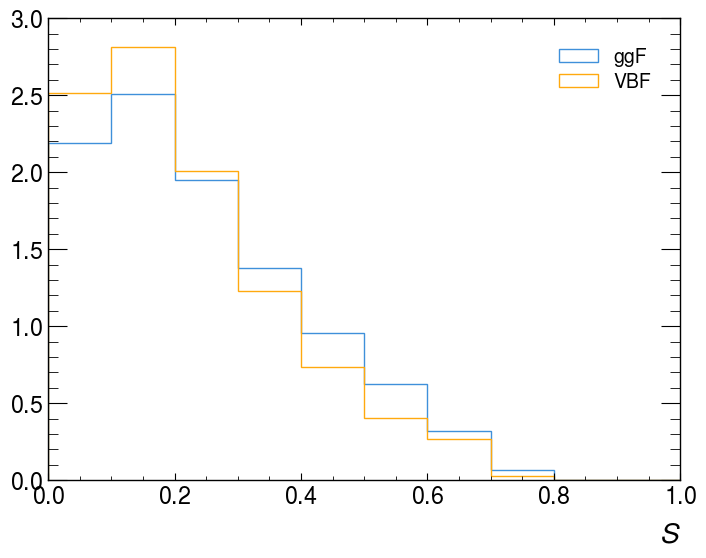

In [18]:
S_bins = np.arange(0, 1.1, .1)
plt.hist(S_list[0], bins=S_bins, histtype='step', density=True, label='ggF')
plt.hist(S_list[1], bins=S_bins, histtype='step', density=True, label='VBF')
plt.legend()
plt.xlabel(r'$S$')
#plt.yscale('log')

Text(1, 0, '$S_\\perp$')

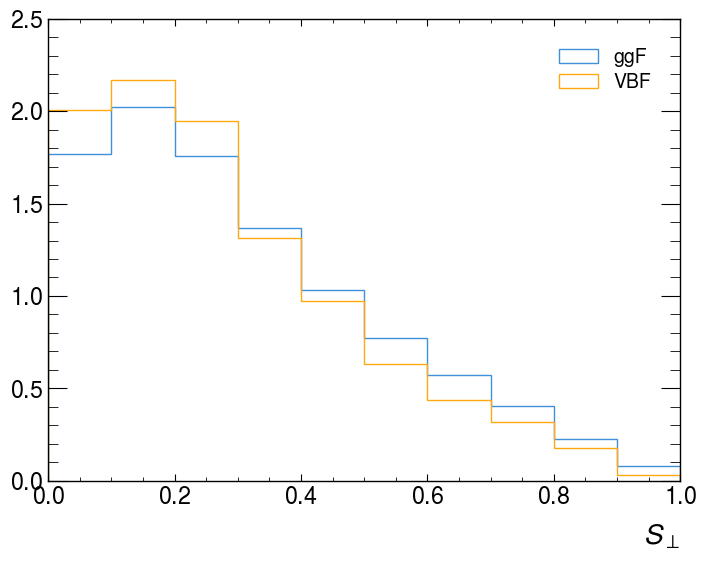

In [19]:
S_bins = np.arange(0, 1.1, .1)
plt.hist(S_perp_list[0], bins=S_bins, histtype='step', density=True, label='ggF')
plt.hist(S_perp_list[1], bins=S_bins, histtype='step', density=True, label='VBF')
plt.legend()
plt.xlabel(r'$S_\perp$')
#plt.yscale('log')

(array([3.81664818e+01, 6.35047575e+00, 2.52641410e+00, 1.19140739e+00,
        6.60790380e-01, 4.12702119e-01, 2.28824937e-01, 1.43015586e-01,
        1.05072675e-01, 7.99719806e-02, 4.55314926e-02, 3.38567509e-02,
        2.33494834e-02, 1.28422159e-02, 7.58858210e-03, 5.83737085e-03,
        3.50242251e-03, 1.75121125e-03, 5.83737085e-04, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00]),
 array([4.35538117e+01, 3.88639761e+00, 1.34529148e+00, 6.53961136e-01,
        2.24215247e-01, 1.30792227e-01

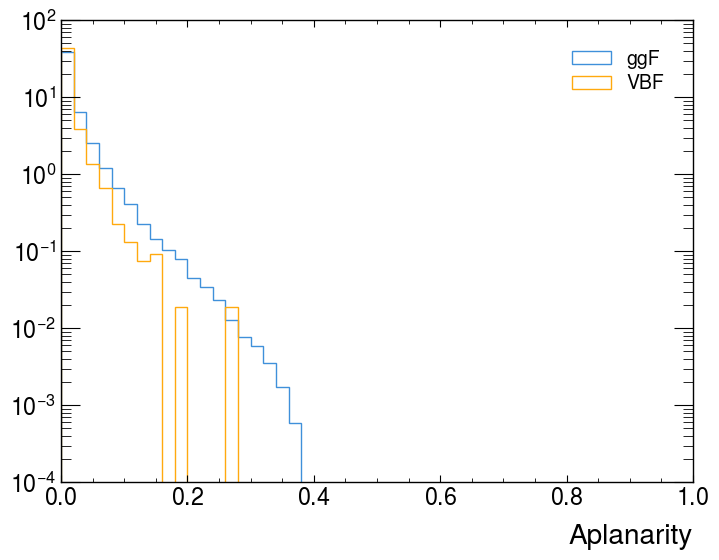

In [22]:
S_bins = np.arange(0, 1, .02)
ggF_num, *_ = plt.hist(A_list[0], bins=S_bins, histtype='step', density=True, label='ggF')
VBF_num, *_ = plt.hist(A_list[1], bins=S_bins, histtype='step', density=True, label='VBF')
plt.legend()
plt.xlabel('Aplanarity')
plt.yscale('log')
ggF_num, VBF_num

#### Planar Flow
2D jet shape in contrast to the linear flow of QCD jets. For a given jet, we can construct a matrix $I_\omega$ as
$$I_\omega^{kl}=\frac{1}{m_J}\sum_i\omega_i\frac{p_{i,k}}{\omega_i}\frac{p_{i,l}}{\omega_i}$$
where $m_J$ is the jet mass, $\omega_i$ is the energy of particle $i$ in the jet, and $p_{i,k}$ is the $k$th component of its transverse momentum relative to the axis of the jet's momentum.

Given $I\omega$, we define planar flow (Pf) for the jet as
$$Pf=\frac{4det(I\omega)}{tr(I\omega)^2}$$

#### Plots

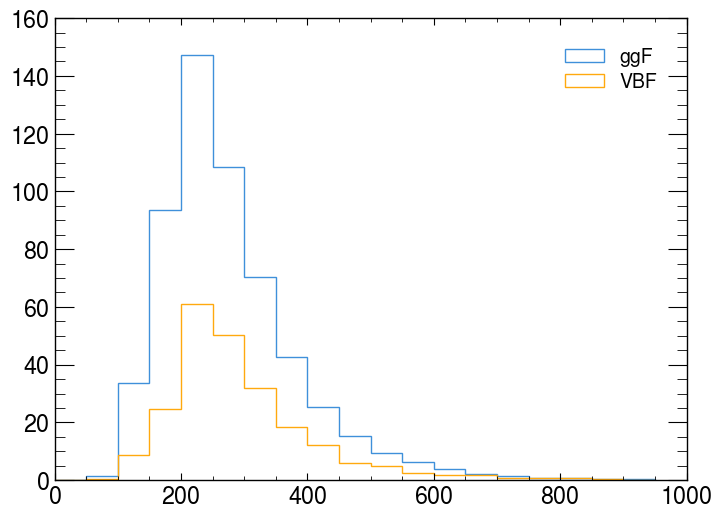

In [30]:
plt.hist((jet_list[0].pt[:,0].compute()), bins=np.arange(0, 1000, 50), histtype='step', weights=eventmcweight_1_list[0].compute()*xSec[0] * intLumi * 1000./sumOfWeightMC[0], label='ggF')
plt.hist((jet_list[1].pt[:,0].compute()), bins=np.arange(0, 1000, 50), histtype='step', weights=eventmcweight_1_list[1].compute()*xSec[1] * intLumi * 1000./sumOfWeightMC[1], label='VBF')
plt.legend()

(0.0, 225.0)

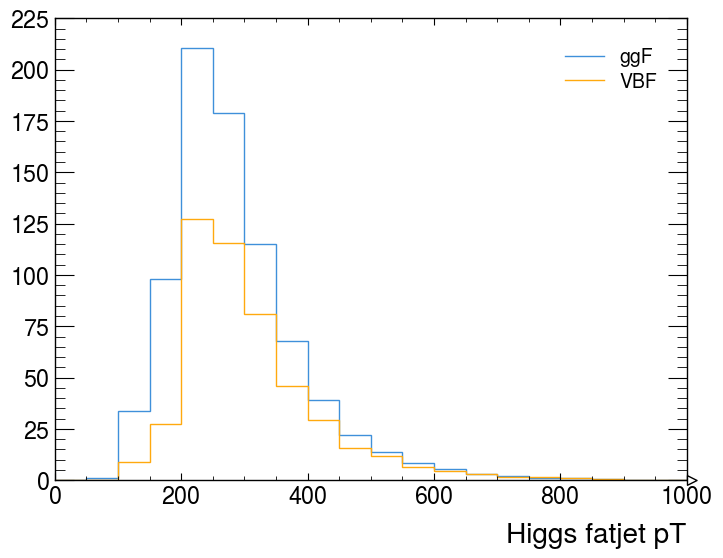

In [1404]:

name = 'Higgs_fatjet_pt'
h = hist_list[name]
h.plot()
plt.legend()
plt.ylim(0, None)
#plt.xlim(h.to_numpy()[2][0], None)#'''

In [31]:
ggF_Higgs_fatjet_vec4.phi[ggF_eventNumber==ggF_eventNumber[ak.num(ggF_Recoil_fatjet_vec4)==4][0]].compute(), ggF_Recoil_fatjet_vec4.phi[ak.num(ggF_Recoil_fatjet_vec4)==3].compute(), VBF_eventNumber[ak.num(VBF_jet)==2].compute()

NameError: name 'ggF_Higgs_fatjet_vec4' is not defined

"\ntotal_num, b, *_ = axs[1].hist(ak.flatten(VBF_jet.pt.compute()), bins=pt_bins, histtype='step', label='all jets')\nleading_num, b, *_ = axs[1].hist((VBF_jet.pt[:,0].compute()), bins=pt_bins, histtype='step', label='leading jets')\nsubleading_num, b, *_ = axs[1].hist((VBF_jet.pt[:,1].compute()), bins=pt_bins, histtype='step', label='subleading jets')\naxs[1].stairs(total_num - (leading_num + subleading_num), edges=pt_bins, label='rest jets', color='green')\naxs[1].legend()\naxs[1].set_xlabel('VBF pT')\naxs[0].set_ylabel('Number of events')"

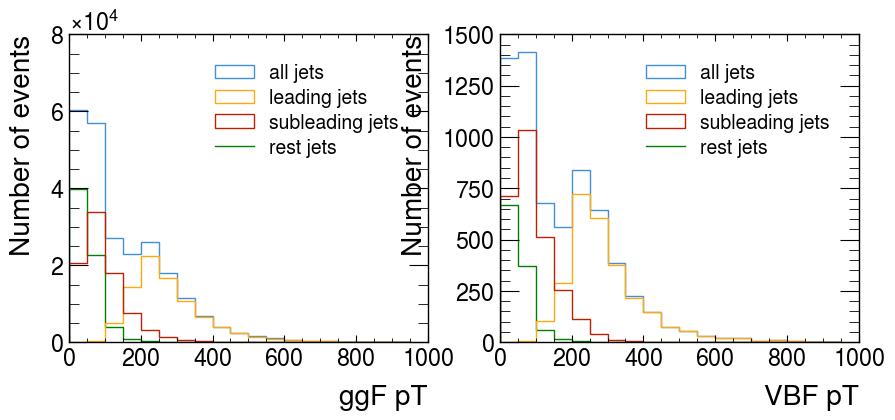

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
pt_bins = np.arange(0, 1000, 50)
for i in range(2):
    total_num, b, *_ = axs[i].hist(ak.flatten(jet_list[i].pt.compute()), bins=pt_bins, histtype='step', label='all jets')
    leading_num, b, *_ = axs[i].hist((jet_list[i].pt[:,0].compute()), bins=pt_bins, histtype='step', label='leading jets')
    subleading_num, b, *_ = axs[i].hist((jet_list[i].pt[:,1].compute()), bins=pt_bins, histtype='step', label='subleading jets')
    axs[i].stairs(total_num - (leading_num + subleading_num), edges=pt_bins, label='rest jets', color='green')
    axs[i].legend()
    axs[i].set_xlabel(f'{production_modes[i]} pT')
    axs[i].set_ylabel('Number of events')

In [1416]:
def d_eta_phi_R(ggF_jet):
    ggF_leading_jet_vec4 = vector.array({"x": ggF_jet.px[:,0].compute(), "y": ggF_jet.py[:,0].compute(), "z": ggF_jet.pz[:,0].compute(), "t": ggF_jet.t[:,0].compute()})
    ggF_subleading_jet_vec4 = vector.array({"x": ggF_jet.px[:,1].compute(), "y": ggF_jet.py[:,1].compute(), "z": ggF_jet.pz[:,1].compute(), "t": ggF_jet.t[:,1].compute()})
    sum_jet = ggF_leading_jet_vec4.add(ggF_subleading_jet_vec4)
    m_jj = sum_jet.tau
    delta_eta = ggF_leading_jet_vec4.deltaeta(ggF_subleading_jet_vec4)
    delta_phi = ggF_leading_jet_vec4.deltaphi(ggF_subleading_jet_vec4)
    delta_R = ggF_leading_jet_vec4.deltaR(ggF_subleading_jet_vec4)
    return delta_eta, delta_phi, delta_R, m_jj
ggF_delta_eta, ggF_delta_phi, ggF_delta_R, ggF_mjj = d_eta_phi_R(jet_list[0])
VBF_delta_eta, VBF_delta_phi, VBF_delta_R, VBF_mjj = d_eta_phi_R(jet_list[1])

In [1430]:
sumOfWeightMC, ak.sum(events_list[0].eventMCWeight.compute()), ak.sum(events_list[1].eventMCWeight.compute())

([226000.0, 2110000.0], 196409.2, 127530.51)

In [47]:
ggF_weights = eventmcweight_1_list[0].compute()*xSec[0] * intLumi * 1000./sumOfWeightMC[0]
VBF_weights = eventmcweight_1_list[1].compute()*xSec[1] * intLumi * 1000./sumOfWeightMC[1]

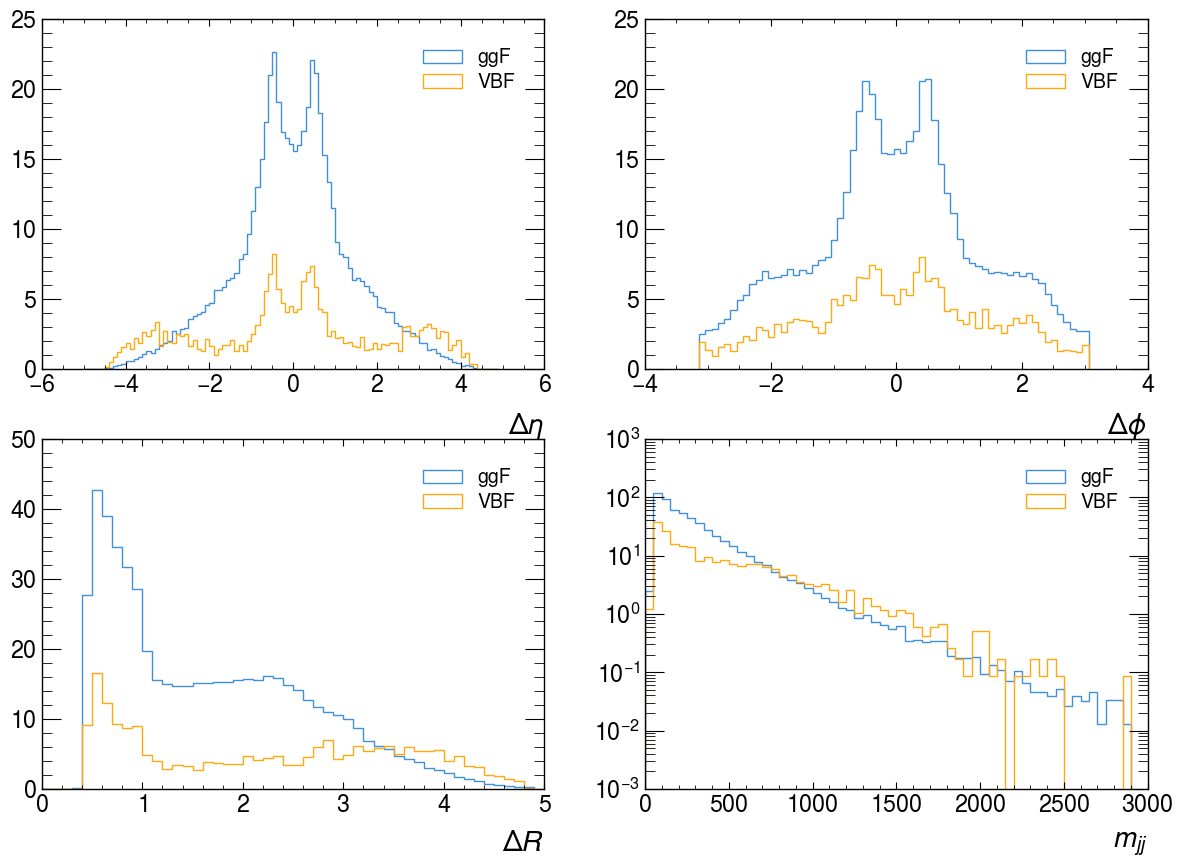

In [1420]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))
ggF_num, b, *_ = axs[0][0].hist(ggF_delta_eta, bins=np.arange(-5, 5, .1), weights=ggF_weights, histtype='step', label='ggF')
VBF_num, b, *_ = axs[0][0].hist(VBF_delta_eta, bins=np.arange(-5, 5, .1), weights=VBF_weights, histtype='step', label='VBF')
axs[0][0].set_xlabel(r'$\Delta\eta$')
axs[0][0].legend()
axs[0][1].hist(ggF_delta_phi, bins=np.arange(-np.pi, np.pi, .1), weights=ggF_weights, histtype='step', label='ggF')
axs[0][1].hist(VBF_delta_phi, bins=np.arange(-np.pi, np.pi, .1), weights=VBF_weights, histtype='step', label='VBF')
axs[0][1].set_xlabel(r'$\Delta\phi$')
axs[0][1].legend()
axs[1][0].hist(ggF_delta_R, bins=np.arange(0, 5, .1), weights=ggF_weights, histtype='step', label='ggF')
axs[1][0].hist(VBF_delta_R, bins=np.arange(0, 5, .1), weights=VBF_weights, histtype='step', label='VBF')
axs[1][0].set_xlabel(r'$\Delta R$')
axs[1][0].legend()
axs[1][1].hist(ggF_mjj, bins=np.arange(0, 3000, 50), weights=ggF_weights, histtype='step', label='ggF')
axs[1][1].hist(VBF_mjj, bins=np.arange(0, 3000, 50), weights=VBF_weights, histtype='step', label='VBF')
axs[1][1].set_xlabel(r'$m_{jj}$')
axs[1][1].set_yscale('log')
axs[1][1].legend()
fig.savefig('ggF_VBF_delta_eta_phi_R_mjj.png', dpi=200)

In [57]:
import vector

def calculate_kt(ggF_jet, ggF_Higgs_fatjet):
    ggF_leading_jet_p = vector.array({"x": ggF_jet.px[:,0].compute(), "y": ggF_jet.py[:,0].compute(), "z": ggF_jet.pz[:,0].compute()})
    ggF_subleading_jet_p = vector.array({"x": ggF_jet.px[:,1].compute(), "y": ggF_jet.py[:,1].compute(), "z": ggF_jet.pz[:,1].compute()})
    # Recoiling jets: the opposite to the Higgs fatjet 4-momentum
    ggF_Recoil_fatjet_p = vector.array({"x": -ggF_Higgs_fatjet.px[:,0].compute(), "y": -ggF_Higgs_fatjet.py[:,0].compute(), "z": -ggF_Higgs_fatjet.pz[:,0].compute()})
    # kt: perpendicular to recoiling fatjet direction
    leading_kt = (ggF_leading_jet_p.cross(ggF_Recoil_fatjet_p)).mag/ggF_Recoil_fatjet_p.mag
    subleading_kt = (ggF_subleading_jet_p.cross(ggF_Recoil_fatjet_p)).mag/ggF_Recoil_fatjet_p.mag
    kt = leading_kt + subleading_kt
    
    return leading_kt, subleading_kt, kt

ggF_leading_kt, ggF_subleading_kt, ggF_kt = calculate_kt(jet_list[0], Higgs_fatjet_vec4_list[0])
VBF_leading_kt, VBF_subleading_kt, VBF_kt = calculate_kt(jet_list[1], Higgs_fatjet_vec4_list[1])
kt_list = []
for i in range(2):
    kt_list.append(calculate_kt(jet_list[i], Higgs_fatjet_vec4_list[i]))

Text(1, 0, 'ggF kt')

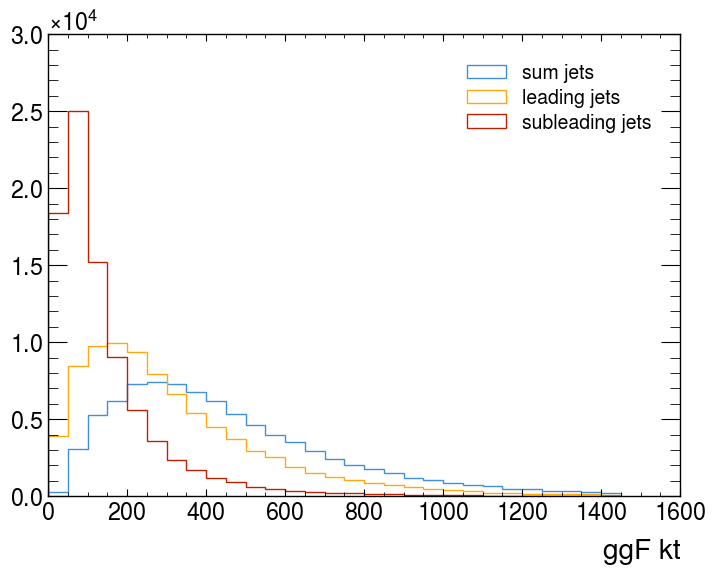

In [55]:
kt_bins=np.arange(0, 1500, 50)
total_num, b, *_ = plt.hist((ggF_kt), bins=kt_bins, histtype='step', label='sum jets')
leading_num, b, *_ = plt.hist((ggF_leading_kt), bins=kt_bins, histtype='step', label='leading jets')
subleading_num, b, *_ = plt.hist((ggF_subleading_kt), bins=kt_bins, histtype='step', label='subleading jets')
#plt.stairs(total_num - (leading_num + subleading_num), edges=np.arange(0, 1000, 50), label='rest jets', color='green')
plt.legend()
plt.xlabel('ggF kt')

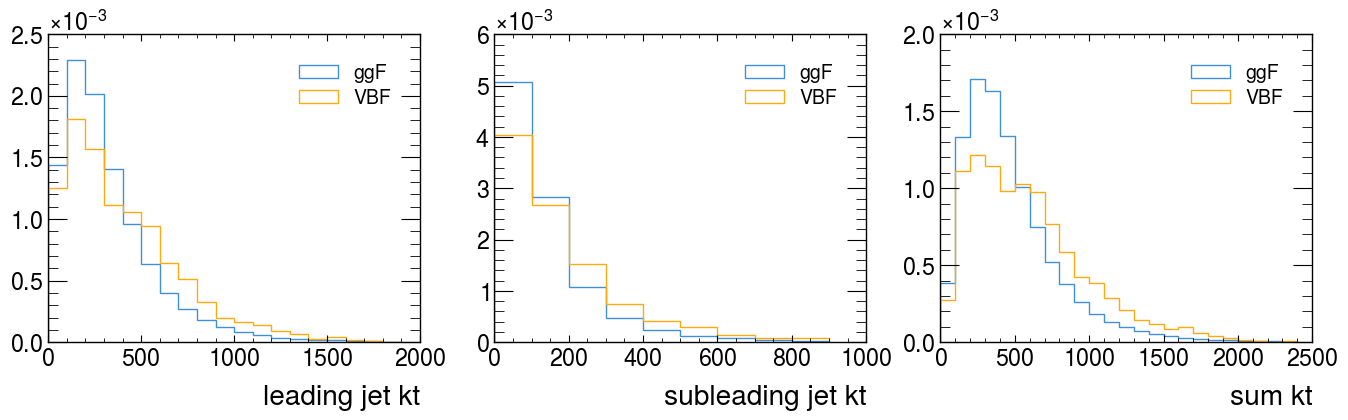

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
pt_bins = [np.arange(0, 2000, 100), np.arange(0, 1000, 100), np.arange(0, 2500, 100)]
xlabel=['leading jet kt', 'subleading jet kt', 'sum kt']
for i in range(3):
    axs[i].hist(kt_list[0][i], bins = pt_bins[i], histtype='step', density=True, weights=ggF_weights, label='ggF')
    axs[i].hist(kt_list[1][i], bins = pt_bins[i], histtype='step', density=True, weights=VBF_weights, label='VBF')
    axs[i].set_xlabel(xlabel[i])
    axs[i].legend()

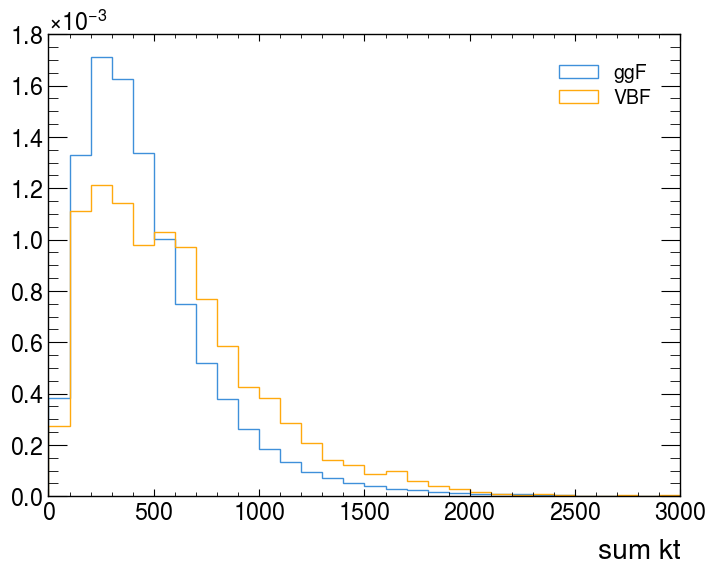

In [54]:
#plt.hist(ak.num(ggF_Recoil_fatjet_vec4).compute(), bins=np.arange(0, 6, 1)) # The number of recoiling fatjets
pt_bins = np.arange(0, 3100, 100)
plt.hist(ggF_kt, bins = pt_bins, histtype='step', density=True, weights=ggF_weights, label='ggF')
plt.hist(VBF_kt, bins = pt_bins, histtype='step', density=True, weights=VBF_weights, label='VBF')
plt.xlabel('sum kt')
plt.legend()
#plt.yscale('log')

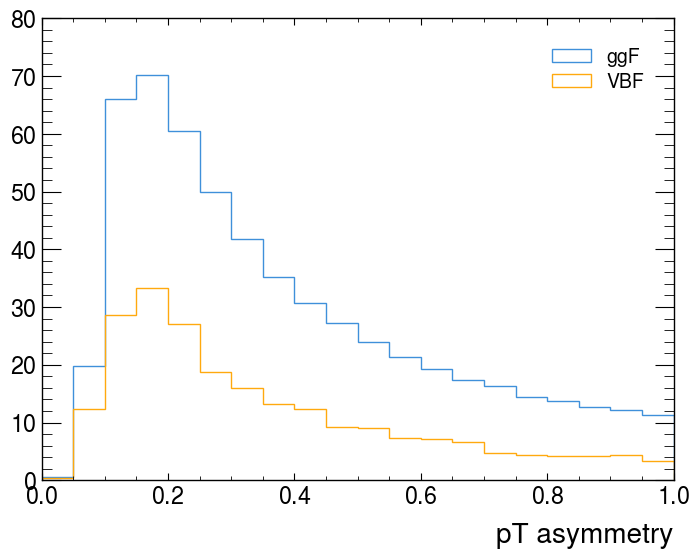

In [1421]:
dt = .05
asymmetry_bins = np.arange(0, 1+dt, dt)
plt.hist((ggF_jet_pt[:,1]/ggF_jet_pt[:,0]), bins=asymmetry_bins, histtype='step', weights=ggF_weights, label='ggF')
plt.hist((VBF_jet_pt[:,1]/VBF_jet_pt[:,0]), bins=asymmetry_bins, histtype='step', weights=VBF_weights, label='VBF')
plt.xlabel('pT asymmetry')
plt.legend()

In [22]:

choice = 1
production_mode = production_modes[choice]
boson_vec4=boson_vec4_0[choice]
jet_vec4 = jet_vec4_0[choice]
fatjet_vec4 = fatjet_vec4_0[choice]
vrjet_vec4 = vrjet_vec4_0[choice]
GN2XbbScore[choice]



dask.awkward<getitem, npartitions=1>

In [401]:
def generate_total_jet_mass(jet_vec4, dR_Jj_1):
    jet_mass = []
    jet_pt = []
    for jet in jet_vec4[dR_Jj_1>1.0].compute():
        if ak.num(jet, axis=-1) != 0:
            total_jets = jet[0]
            for i in range(1, len(jet)):
                total_jets = jet[i] + total_jets
            jet_mass.append(total_jets.mass)
            jet_pt.append(total_jets.pt)
    return jet_mass, jet_pt

In [340]:
jet_mass, jet_pt = generate_total_jet_mass(jet_vec4, dR_Jj_1)

In [315]:
mass.append(jet_mass)

In [308]:
mass = []
mass.append(jet_mass)

In [551]:
VBF_num

array([ 1., 10.,  8.,  0.,  4.,  1.,  3.,  1.,  1.,  1.,  3.,  3.,  1.,
        0.,  2.,  0.,  0.,  3.,  1.,  0.,  2.,  1.,  0.,  1.,  0.,  0.,
        1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        1.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
        0.,  0.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,
        0.,  0.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  1.,
        0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.])

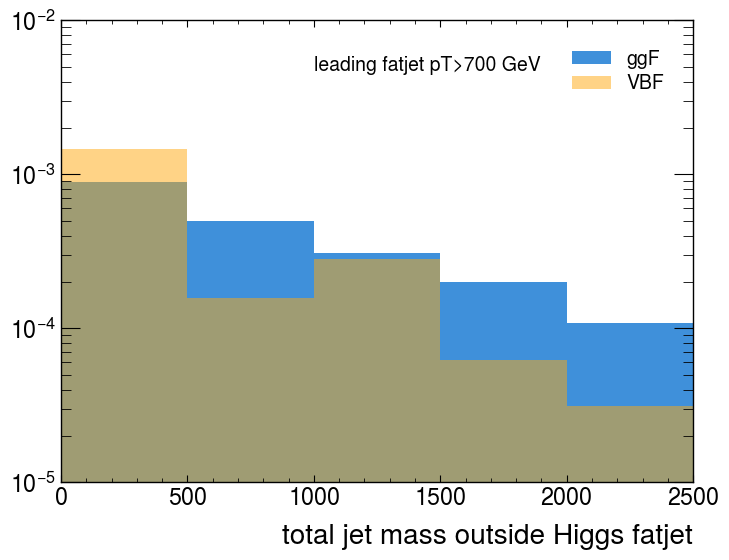

In [554]:
plt.xlabel(f'total jet mass outside Higgs fatjet')
#plt.xlabel(f'total jet mass outside Higgs fatjet {production_mode}')
ggF_num, b, *_ = plt.hist(mass[0], bins=np.arange(0,3000,500), density=True, label='ggF')
VBF_num, b, *_ = plt.hist(mass[1], bins=np.arange(0,3000,500), density=True, alpha=.5, label='VBF')
#num, b, *_ = plt.hist(jet_mass, bins=np.arange(0,3000,50), density=True)

plt.text(1000, max(num), 'leading fatjet pT>700 GeV')
plt.legend()
plt.yscale('log')

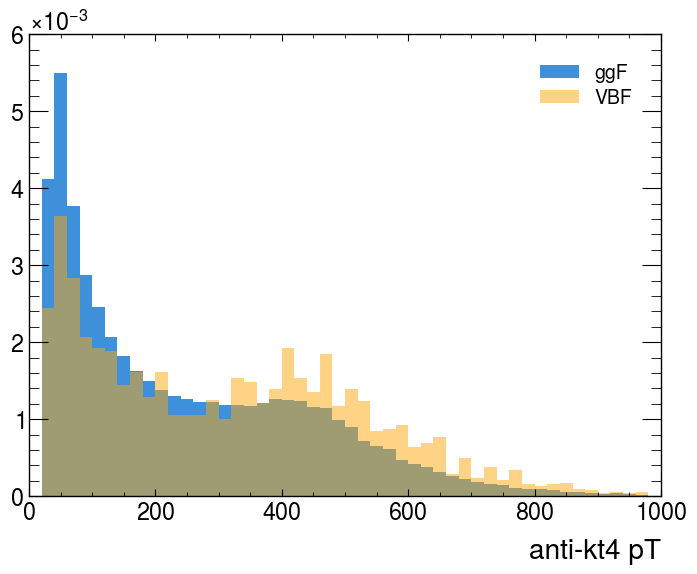

In [403]:
plt.hist(ak.flatten(jet_vec4_0[0].pt).compute(), bins=np.arange(0, 1000, 20), density=True, label='ggF')
plt.hist(ak.flatten(jet_vec4_0[1].pt).compute(), bins=np.arange(0, 1000, 20), density=True, alpha=0.5, label='VBF')
#plt.hist(ak.max(jet_vec4_0[0].pt, axis=-1).compute(), bins=np.arange(0, 1200, 20), density=True, label='ggF')
#plt.hist(ak.max(jet_vec4_0[1].pt, axis=-1).compute(), bins=np.arange(0, 1200, 20), density=True, alpha=0.5, label='VBF')
plt.xlabel('anti-kt4 pT')
plt.legend()

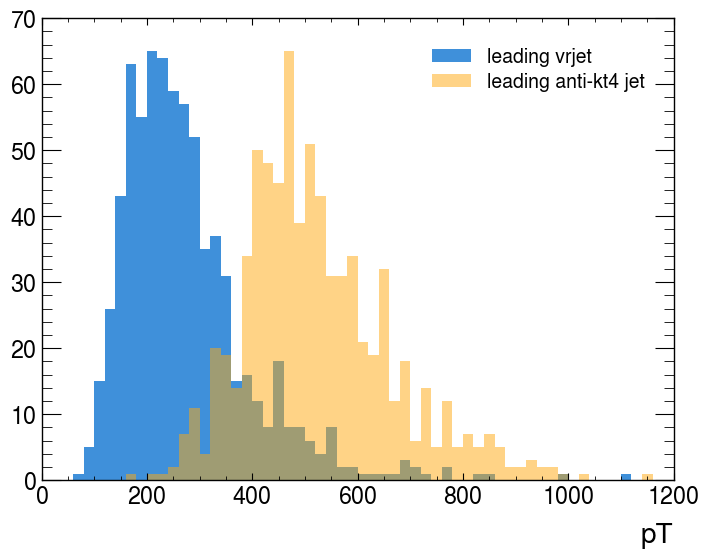

In [527]:
plt.hist(ak.max(vrjet_vec4.pt, axis=-1).compute(), bins=np.arange(0, 1200, 20), label='leading vrjet')
plt.hist(ak.max(jet_vec4.pt, axis=-1).compute(), bins=np.arange(0, 1200, 20), alpha=0.5, label='leading anti-kt4 jet')
#plt.hist(ak.flatten(vrjet_vec4.pt).compute(), bins=np.arange(0, 1000, 20), label='vrjet')
#plt.hist(ak.flatten(jet_vec4.pt).compute(), bins=np.arange(0, 1000, 20), alpha=0.5, label='anti-kt4 jet')
plt.xlabel('pT')
plt.legend()

In [161]:
b = a[0]
for i in range(1, len(a)):
    b = a[i] + b
b

<LorentzVectorRecord {x: 327, y: 415, z: 2.12e+03, ...} type='LorentzVector...'>

Text(1, 0, '$\\eta$')

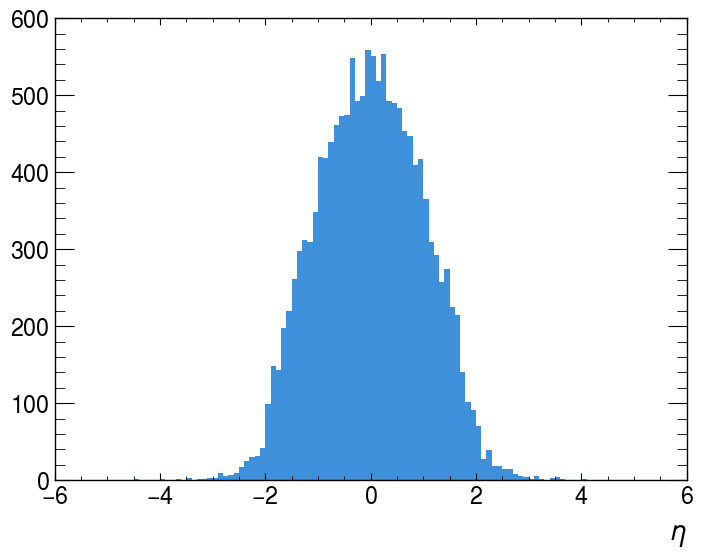

In [25]:
plt.hist(boson_vec4.eta.compute()[:,0], bins=np.arange(-4.5, 4.5, .1))
plt.xlabel(r'$\eta$')

(array([  0.,   0.,   0.,   0.,  37.,  36.,  60.,  79., 107., 416., 220.,
        167., 110.,  56.,  49.,  27.,  20.,   6.,   8.,   3.,   2.,   2.,
          1.,   0.,   1.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
         900.,  950., 1000., 1050., 1100., 1150., 1200., 1250., 1300.,
        1350., 1400., 1450., 1500., 1550., 1600., 1650., 1700., 1750.,
        1800., 1850., 1900., 1950.]),
 <BarContainer object of 39 artists>)

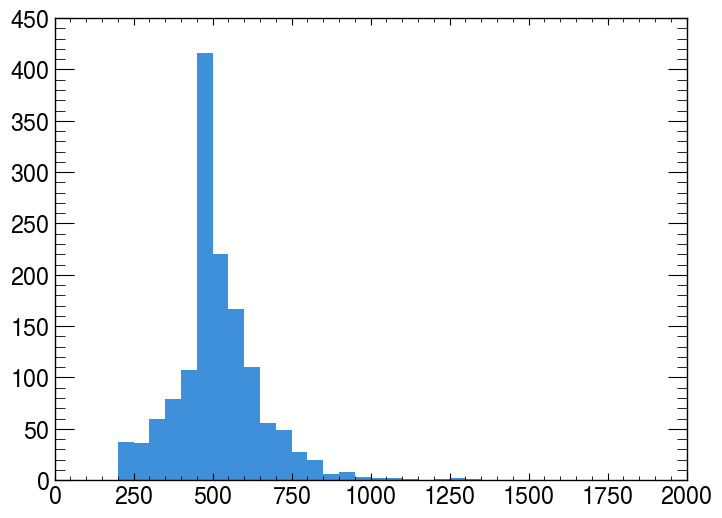

In [242]:
plt.hist(ak.flatten(fatjet_vec4.pt.compute()), bins=np.arange(0, 2000, 50))

Text(1, 0, 'jets pT outside of Higgs fatjet VBF')

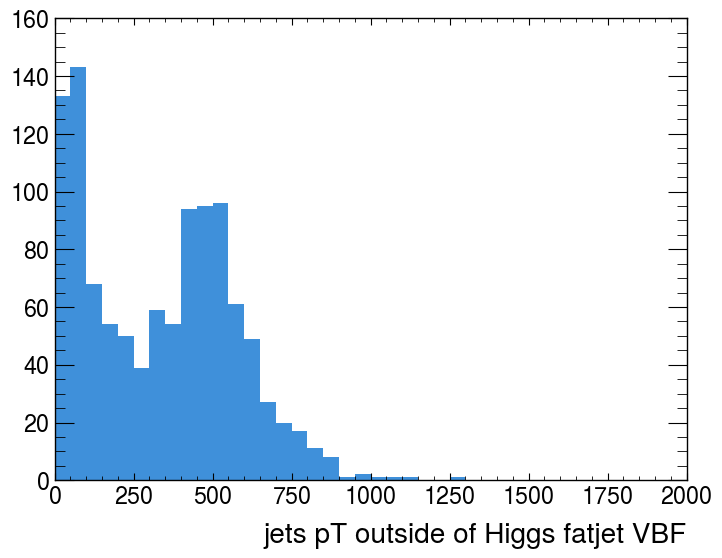

In [243]:
plt.hist(ak.flatten(jet_vec4[dR_Jj_1>1.0].pt.compute()), bins=np.arange(0, 2000, 50))
plt.xlabel(f"jets pT outside of Higgs fatjet {production_mode}")

(array([102., 466., 125.,  30.,   3.,   7.,   3.,   0.,   0.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

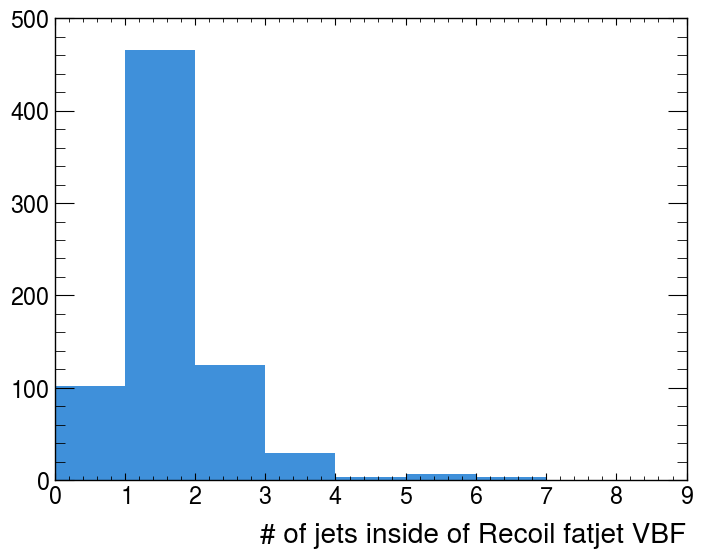

In [245]:
plt.xlabel(f"# of jets inside of Recoil fatjet {production_mode}")
plt.hist(ak.num(dR_Jj_2[dR_Jj_2<1.0]), bins=np.arange(0, 10, 1))

In [1422]:
ak.sum(eventmcweight[choice]).compute()

3082.3188

/usr/local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:246: RuntimeWarning: invalid value encountered in sqrt
  return impl(*broadcasted_args, **(kwargs or {}))


0.9766595

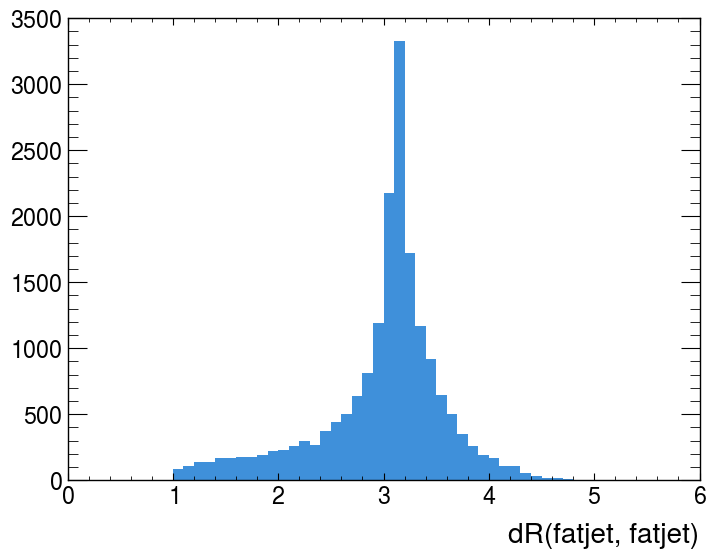

In [1375]:
m_jj, dR_jj = calculate_self_values(fatjet_vec4)
plt.hist(ak.flatten(dR_jj), bins = np.arange(0, 6.0, .1))
plt.xlabel('dR(fatjet, fatjet)')
min(ak.flatten(dR_jj))

(array([0.000e+00, 0.000e+00, 8.322e+03, 2.371e+03, 5.720e+02, 1.530e+02,
        6.000e+01, 3.100e+01, 3.000e+00]),
 array([  0., 100., 200., 300., 400., 500., 600., 700., 800., 900.]),
 <BarContainer object of 9 artists>)

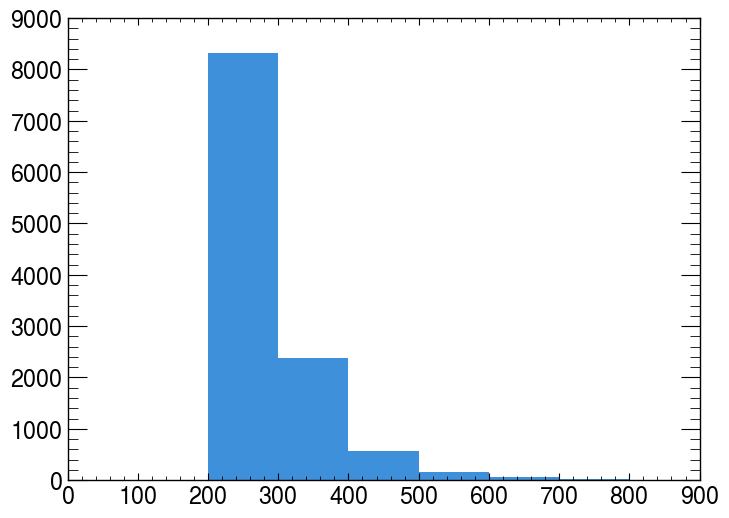

In [572]:
plt.hist(ak.min(fatjet_vec4.pt.compute(), axis=-1), bins=np.arange(0, 1000, 100))

In [1000]:
VBF_list = VBF_eventNumber[ak.num(VBF_jet)==0].compute()
VBF_list

<Array [82262, 40184, ..., 277679, 277871] type='5772 * int32[parameters={"...'>

(array([5772., 3055., 1868.,  603.,  203.]),
 array([0., 1., 2., 3., 4., 5.]),
 <BarContainer object of 5 artists>)

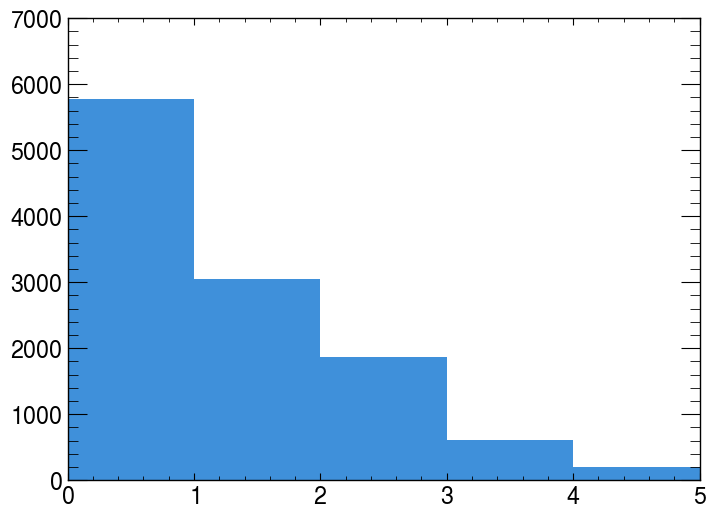

In [999]:
plt.hist(ak.num(VBF_jet, axis=-1).compute(), bins=np.arange(0, 6, 1))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 1, '$\\phi$')

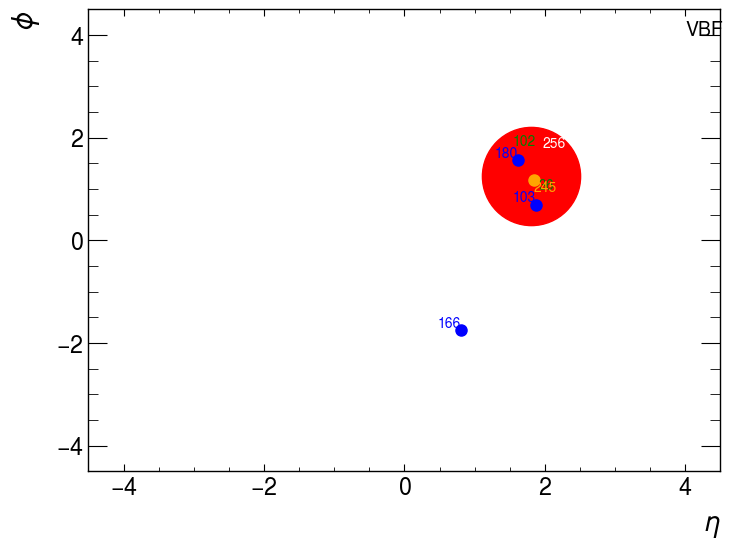

In [1005]:
mask = (eventNumber[choice]==56043)
index = 0
fatjet_eta, fatjet_phi = fatjet_vec4[mask].eta[index].compute(), fatjet_vec4[mask].phi[index].compute()
boson_eta, boson_phi = boson_vec4[mask].eta[index].compute()[0], boson_vec4[mask].phi[index].compute()[0]
jet_eta, jet_phi = jet_vec4[mask].eta[index].compute(), jet_vec4[mask].phi[index].compute()
vrjet_eta, vrjet_phi = vrjet_vec4[mask].eta[index].compute(), vrjet_vec4[mask].phi[index].compute()

plt.scatter(fatjet_eta, fatjet_phi, color='red', s=5000)
#plt.errorbar(fatjet_eta, fatjet_phi, yerr=[np.pi/2, np.pi/2], linestyle='')
plt.scatter(boson_eta, boson_phi, color='orange')
plt.scatter(jet_eta, jet_phi, color='blue')
#plt.scatter(vrjet_eta, vrjet_phi, color='green')

#plt.scatter([-0.754], [2.1])
for i in range(len(jet_eta)):
    plt.text(jet_eta[i], jet_phi[i], f"{jet_vec4[mask].pt[index].compute()[i]:.0f}", fontsize=10, ha='right', va='bottom', color='blue')
    
for i in range(len(fatjet_eta)):
    plt.text(fatjet_eta[i]+.5, fatjet_phi[i]+.5, f"{fatjet_vec4[mask].pt[index].compute()[i]:.0f}", fontsize=10, ha='right', va='bottom', color='white')
    
for i in range(len(vrjet_eta)):
    plt.text(vrjet_eta[i]+.25, vrjet_phi[i]+.25, f"{vrjet_vec4[mask].pt[index].compute()[i]:.0f}", fontsize=10, ha='right', va='bottom', color='green')

#k = -1./((fatjet_phi[1] - fatjet_phi[0])/(fatjet_eta[1] - fatjet_eta[0]))
#x = np.arange(-4.5, 4.5, .01)
#plt.plot(x, k*x+sum(fatjet_phi)/2-k*sum(fatjet_eta)/2)

plt.text(4, 4, f'{production_modes[choice]}')

plt.text(boson_eta, boson_phi, f"{boson_vec4[:,0].pt[index].compute():.0f}", fontsize=10, color='orange', ha='left', va='top')
#plt.plot(np.linspace(-4.5, 4.5, 100), np.ones(100)*np.pi, color='k')
#plt.plot(np.linspace(-4.5, 4.5, 100), -1*np.ones(100)*np.pi, color='black')
plt.legend()
plt.ylim(-4.5, 4.5)
plt.xlim(-4.5, 4.5)
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\phi$')

(array([6.748e+03, 4.015e+03, 2.676e+03, 1.719e+03, 1.089e+03, 4.700e+02,
        1.820e+02, 6.100e+01, 4.300e+01, 8.000e+00, 3.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
         900.,  950., 1000., 1050., 1100., 1150.]),
 <BarContainer object of 23 artists>)

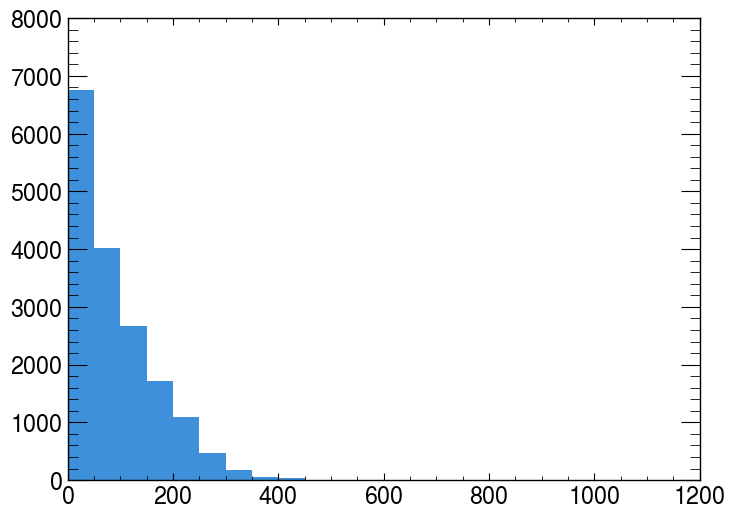

In [101]:
plt.hist(ak.flatten(Recoil_fatjet_vec4.mass.compute()), bins=np.arange(0, 1200, 50))

In [81]:
fatjets_2.phi

<Array [[0.879, 0.879, 0.879], ..., [-1.36, ...]] type='736 * var * float32'>

<ErrorbarContainer object of 3 artists>

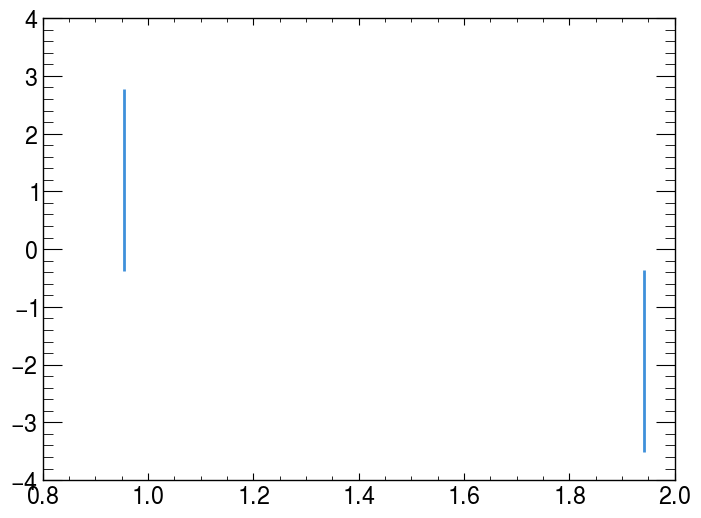

In [68]:
plt.errorbar(fatjet_eta, fatjet_phi, yerr=[np.pi/2, np.pi/2], linestyle='')

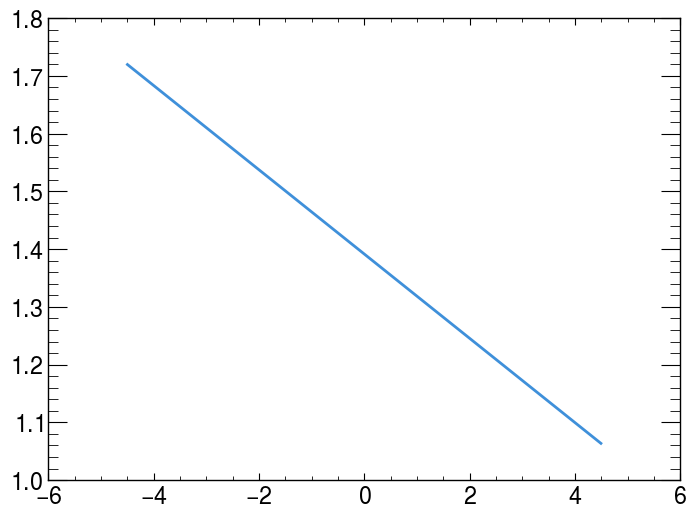

In [53]:
k = -1./((fatjet_phi[1] - fatjet_phi[0])/(fatjet_eta[1] - fatjet_eta[0]))
x = np.arange(-4.5, 4.5, .01)
plt.plot(x, k*x+sum(fatjet_phi)/2-k*sum(fatjet_eta)/2)

0.019021739130434784

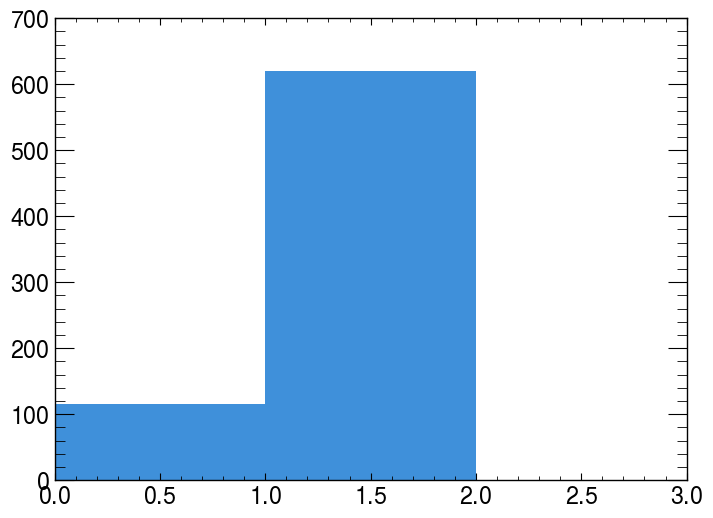

In [1297]:
num_one_fatjet = ak.num(fatjet_vec4[ak.num(fatjet_vec4)==1], axis=0).compute()
values, Bins, _ = plt.hist((ak.num(fatjet_vec4_1).compute()), bins=np.arange(0, 4, 1))
(values[0]-num_one_fatjet)/np.sum(values) # Higgs not matching to any of the fatjet

In [1376]:
#ak.num(jet_vec4[dR_Jj<1.0])
#a = jet_vec4[fj_num_cut]
#ak.num(jet_vec4.pt[dR_Jj_1 < 1.0]).compute()
#ak.num(jet_vec4).compute()
jets_jets_pair = ak.cartesian([fatjet_vec4, fatjet_vec4]).compute()
jets1 = jets_jets_pair["0"]
jets2 = jets_jets_pair["1"]
mask = (jets1.pt > jets2.pt) # Avoid redundacy, we want C^n_n not A^n_n
deta_jj = abs(jets1.eta[mask]-jets2.eta[mask])
m_jj = (jets1[mask]+jets2[mask]).mass
dR_jj = jets1[mask].delta_r(jets2[mask])
dR_jj[ak.num(dR_jj[dR_jj<1])>0]
eventNumber[choice][ak.num(dR_jj[dR_jj<1])>0].compute()
#fatjet_vec4.pt[eventNumber[0]==1615114].compute()

<Array [130471, 130471, 1615114, 1674417] type='4 * int32[parameters={"__do...'>

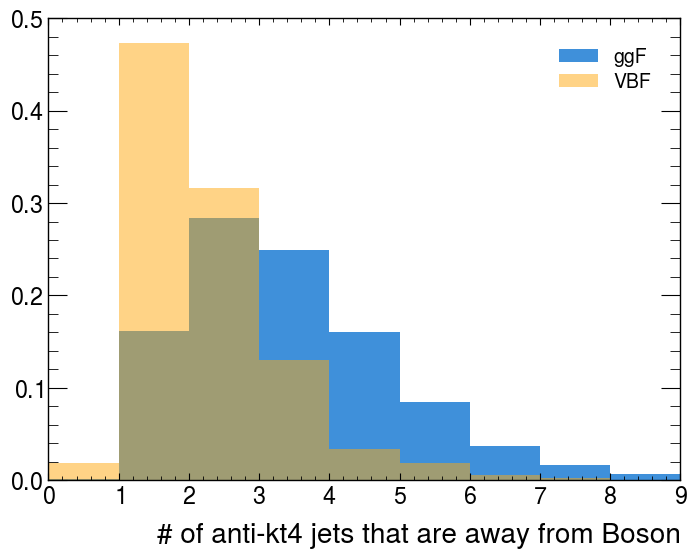

In [418]:
plt.hist(ak.sum(eventmcweight2[0], axis=1), bins=np.arange(0, 10, 1), density=True, label='ggF')
plt.hist(ak.sum(eventmcweight2[1], axis=1), bins=np.arange(0, 10, 1), density=True, alpha=.5, label='VBF')
plt.xlabel('# of anti-kt4 jets that are away from Boson')
plt.legend()

In [860]:
jet_vec4[eventNumber[0]==4088].y.compute()

<Array [[-93.9, 7.13, -32]] type='1 * var * float32[parameters={"__doc__": ...'>

Text(1, 0, 'fatjet pT')

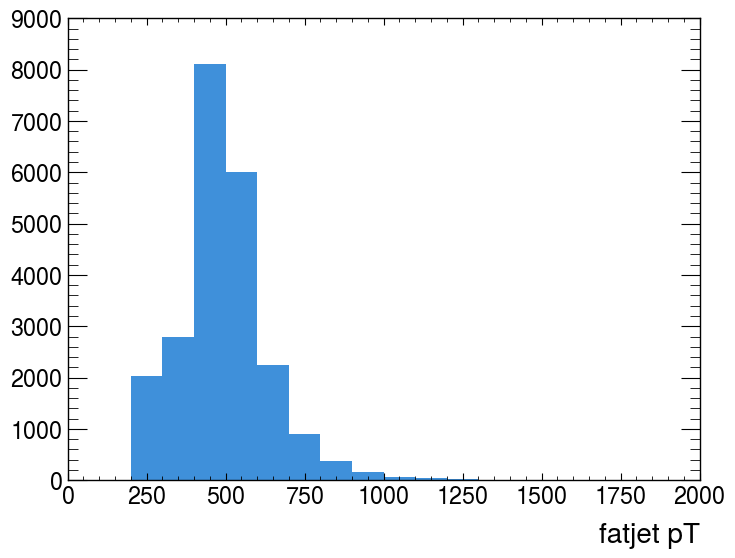

In [858]:
plt.hist(ak.flatten(fatjet_vec4[ak.num(dR_Jj[dR_Jj>1.0])>0].pt.compute()), bins=np.arange(0, 2000, 100))
plt.xlabel('fatjet pT')

Text(1, 0, 'Higgs pT')

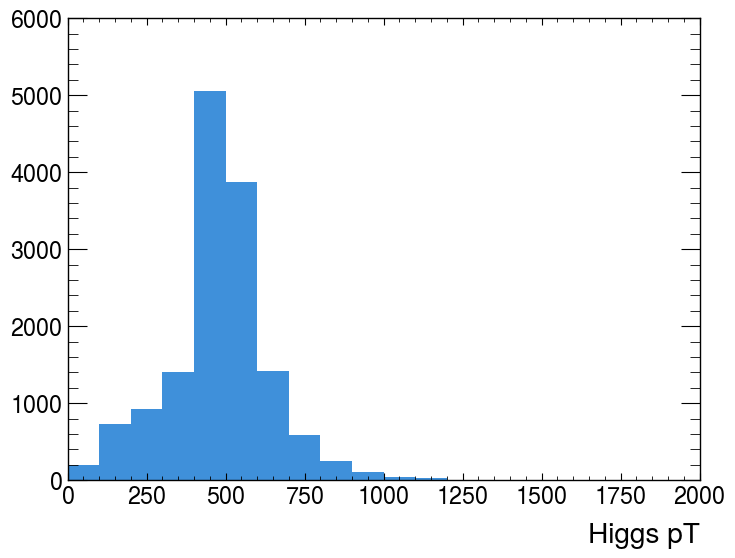

In [857]:
plt.hist((boson_vec4.pt.compute()[:,0]), bins=np.arange(0, 2000, 100))
plt.xlabel('Higgs pT')

Text(1, 0, 'jets pT')

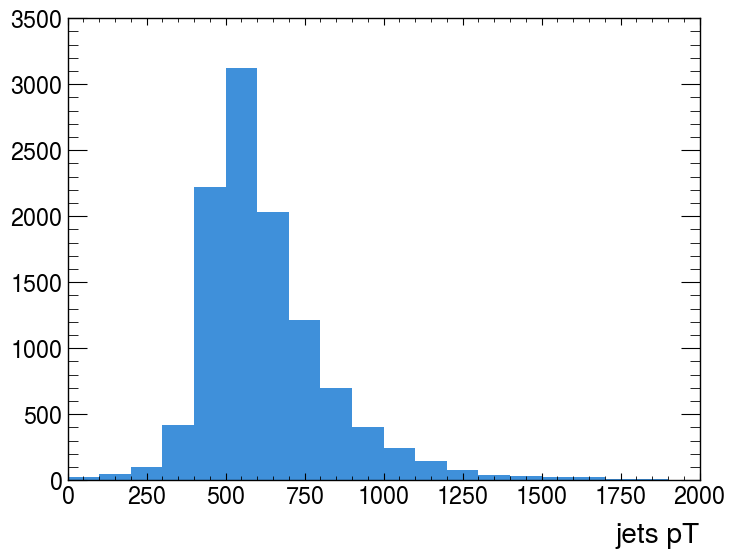

In [856]:
dr = dR_Jj[ak.num(dR_Jj[dR_Jj>1.0])>0]
j = jet_vec4[ak.num(dR_Jj[dR_Jj>1.0])>0].compute()
plt.hist(ak.sum(j[dr>1].pt, axis=-1), bins=np.arange(0, 2000, 100))
#plt.hist((ak.sum(jet_vec4.pt.compute(), axis=-1)), bins=np.arange(0, 3000, 100))
plt.xlabel('jets pT')

In [488]:
boson_vec4[0].eta.compute()
boson_vec4[0].compute()
def Eta(pz, E):
    return 1./2*np.log((E+pz)/(E-pz))
p = np.sqrt(176**2+5.16**2+196**2)
#print(np.sqrt(p**2+125**2))
#print(Eta(-196, p))
#plt.hist(ak.flatten(jet_vec4[0].eta).compute(), bins=np.arange(-5, 5, .1))
#plt.hist(boson_vec4[0].pt[:,0].compute(), bins=np.arange(0, 1700, 100))
#ak.min((boson_vec4[0].pt)).compute()
ak.num(jet_vec4[0]).compute()
ak.num(fatjet_vec4[0]).compute()

<Array [1, 2, 2, 2, 2, 2, 2, 2, ..., 2, 3, 2, 2, 2, 1, 2] type='14642 * int64'>

In [ ]:
i=0
ak.sum(eventweight[i][ak.num(m_jj[i][m_jj[i]>1000])>0]).compute()
#ak.sum(eventweight[i][ak.num(m_jj[i][deta_jj[i]>3.5])>0]).compute()
#ak.sum(eventmcweight[i]).compute()


6640.983

<Array [[3.3, 1.35, 0.284, ..., 3.16, 1.11], ...] type='14683 * var * float32'>

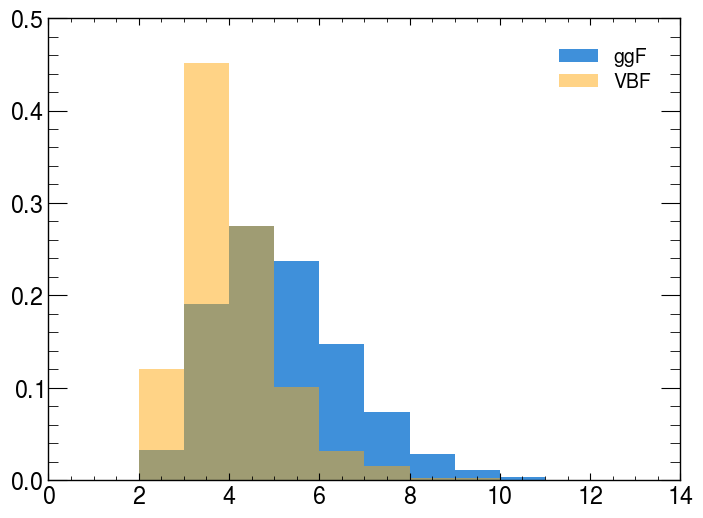

In [278]:
bins=np.arange(0,max(ak.num(dR_Bj[0])), 1)
plt.hist(ak.num(dR_Bj[0]), bins=bins, density=True, label='ggF')
plt.hist(ak.num(dR_Bj[1]), bins=bins, density=True, alpha=.5, label='VBF')
plt.legend()


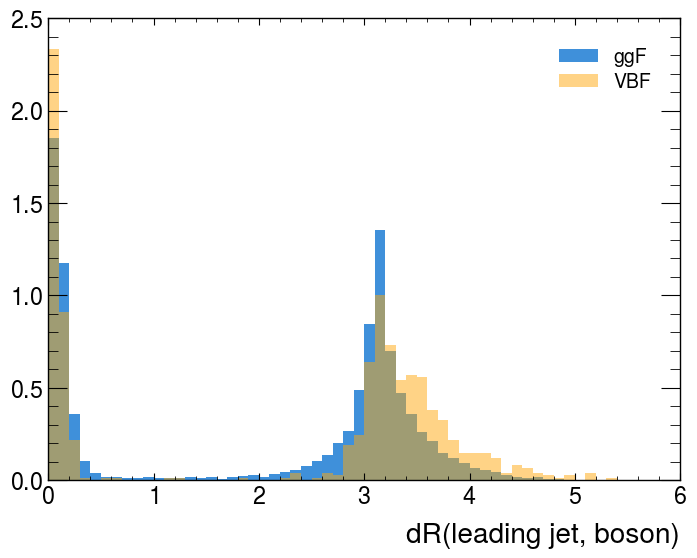

In [263]:
plt.hist(dR_Bj[0][ak.num(dR_Bj[0])>=1][:, 0], bins=bins, density=True, label='ggF')
plt.hist(dR_Bj[1][ak.num(dR_Bj[1])>=1][:, 0], bins=bins, density=True, alpha=.5, label='VBF')
plt.xlabel('dR(leading jet, boson)')
plt.legend()

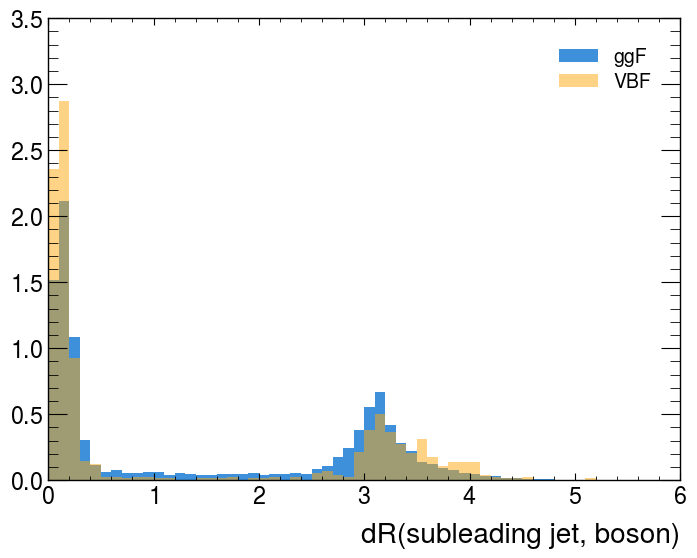

In [262]:

bins=np.arange(0, 6, .1)

plt.hist(dR_Bj[0][ak.num(dR_Bj[0])>=2][:, 1], bins=bins, density=True, label='ggF')
plt.hist(dR_Bj[1][ak.num(dR_Bj[1])>=2][:, 1], bins=bins, density=True, alpha=.5, label='VBF')
plt.xlabel('dR(subleading jet, boson)')
plt.legend()

Text(1, 0, 'dR(boson, jets)')

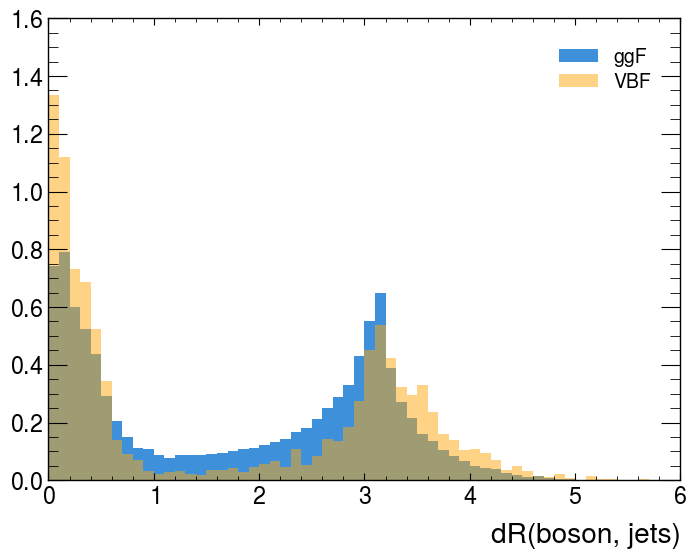

In [261]:
bins=np.arange(0, 6, .1)
plt.hist(ak.flatten(dR_Bj[0]), bins=bins, density=True, label='ggF')
plt.hist(ak.flatten(dR_Bj[1]), bins=bins, density=True, alpha=.5, label='VBF')
plt.legend()
plt.xlabel('dR(boson, jets)')

In [164]:
%%time

from coffea.nanoevents.methods import vector
ip = 1
events = events_list[ip] 

theory_weights = [.00657588, .0842073, 0.00116801]




num_cout_results = []
wei_event_results = []
print('total number', total_number, 'weighted events', ak.sum(events.eventMCWeight.compute()))
for cut, cut_name in zip(cuts[:], selection1.names[:]):
    n_events = ak.sum(selection1.all(cut_name), axis=0)
    wei_events = ak.sum(events.eventMCWeight[selection1.all(cut_name)])
    num_cout_results.append(n_events)
    wei_event_results.append(wei_events)
cut_results, *_ = dask.compute(num_cout_results)
cut_wei_results, *_ = dask.compute(wei_event_results)
for cut, n_events, wei_events in zip(selection1.names, cut_results, cut_wei_results):
    print(f"Events passing '{cut}': {n_events}, {wei_events:.1f}")
    

total number 30326 weighted events 127530.51
Events passing 'fatjet_size_cut': 20205, 84954.0
Events passing 'fatjet_pt_m': 737, 3086.6
Events passing 'jet_pt_m_cut': 30293, 127389.7
Events passing 'boson_pt_m_cut': 30326, 127530.5
Events passing 'num_cut': 19935, 83823.7
Events passing 'combine': 737, 3086.6
Events passing 'combine1': 737, 3086.6
CPU times: user 1.04 s, sys: 42.8 ms, total: 1.08 s
Wall time: 1.9 s


Text(1, 0, '$m_{jj}$')

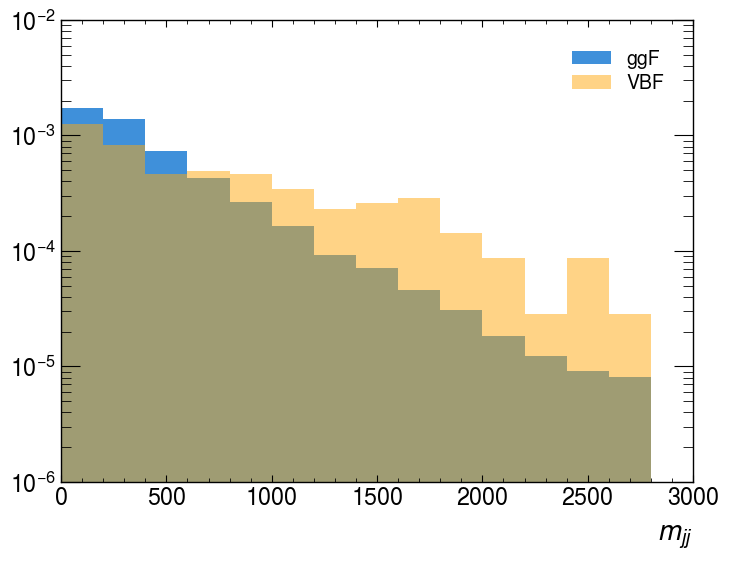

In [188]:
plt.hist(ak.flatten(m_jj[0][ak.any(deta_jj[0]>3.5, axis=-1)]), bins=bins, density=True, label='ggF')
plt.hist(ak.flatten(m_jj[1][ak.any(deta_jj[1]>3.5, axis=-1)]), bins=bins, density=True, alpha=.5, label='VBF')
plt.yscale('log')
plt.legend()
plt.xlabel(r'$m_{jj}$')
plt.savefig(f"test.png")

In [28]:
a = np.array([196409,127531,7938,3087,7936,3087,7064,1823,1091,455,944,374])
#ggF = a[::2]
#VBF = a[1::2]
VBF/np.sqrt(VBF+ggF)

array([17.14950721, 11.66329296,  9.54260257,  9.74736666])

In [116]:
cut_flow = {
    "dR(j, B) > 1": ak.sum(eventmcweight1).compute(),
    "mjj > 1 TeV": ak.sum(eventmcweight1[ak.max(m_jj>1000, axis=-1)]).compute(),
    "eta_jj > 3.5": ak.sum(eventmcweight1[ak.max(deta_jj>3.5, axis=-1)]).compute()
}

In [23]:
a = ak.max(m_jj>1000,axis=-1)
b = ak.max(deta_jj>3.5,axis=-1)
ak.sum(eventmcweight1[a&b].compute())

342.21356

In [24]:
VBF = np.array([1541.8162, 446.78406, 289.2768, 233.97511])
ggF = np.array([6540.9854, 1020.631, 629.6767, 342.21356])

ak.sum(eventmcweight1).compute(), ak.sum(eventmcweight1[a]).compute(), ak.sum(eventmcweight1[b]).compute(), ak.sum(eventmcweight1[a&b]).compute()

(6540.9854, 1020.631, 629.6767, 342.21356)

(array([44., 29., 16., 17., 16., 12.,  8.,  9., 10.,  5.,  3.,  1.,  3.,
         1.]),
 array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400., 1600.,
        1800., 2000., 2200., 2400., 2600., 2800.]),
 <BarContainer object of 14 artists>)

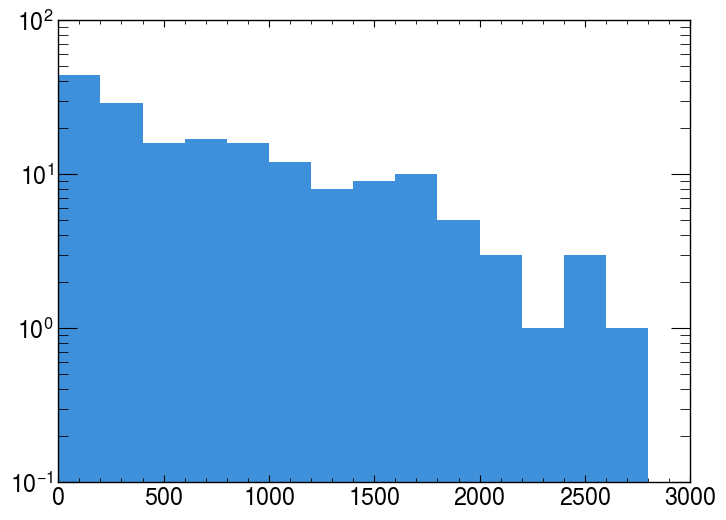

In [117]:
bins= np.arange(0, 3000, 200)
plt.yscale('log')
plt.hist(ak.flatten(m_jj[ak.any(deta_jj>3.5, axis=-1)]), bins=bins)
#plt.hist(ak.flatten(m_jj[ak.any(deta_jj>3.5, axis=-1)]), bins=bins)

In [51]:
mjj_list = []
eta_list = []


In [60]:
if ip == 0:
    mjj_list.append(ak.max(m_jj, axis=-1))
    eta_list.append(ak.max(deta_jj, axis=-1))
elif ip == 1:
    mjj_list.append(ak.max(m_jj, axis=-1))
    eta_list.append(ak.max(deta_jj, axis=-1))

Text(0, 1, '$|\\eta_{jj}|$')

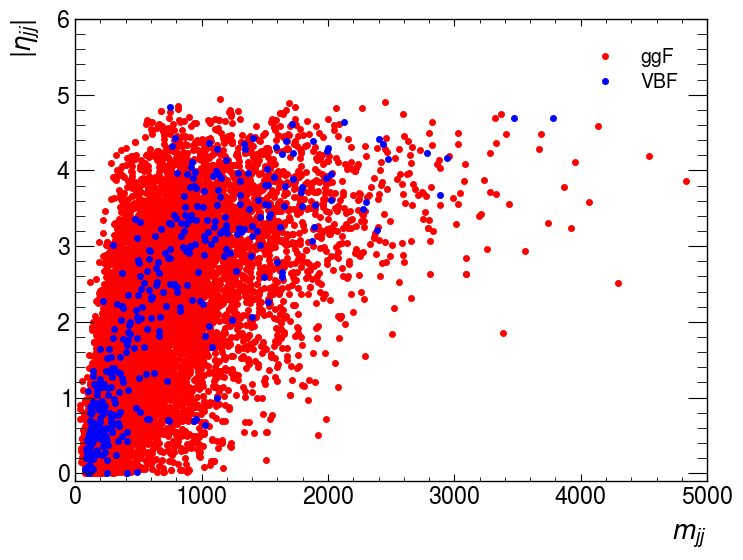

In [61]:
plt.plot(mjj_list[0], eta_list[0], 'r.', label='ggF')
plt.plot(mjj_list[1], eta_list[1], 'b.', label='VBF')
plt.legend()
plt.ylim(-0.1, None)
plt.xlabel(r'$m_{jj}$')
plt.ylabel(r'$|\eta_{jj}|$')

In [78]:
VBF_cut = (deta_jj>3.5) & (m_jj>1000)
CMS_VBF_cut = ak.num(dR_jj[(deta_jj>3.5) & (m_jj>1000)])>=2
ggF = ak.num(dR_jj_list[0][(deta_jj_list[0]>3.5) & (m_jj_list[0]>1000)])>=2
VBF = ak.num(dR_jj_list[1][(deta_jj_list[1]>3.5) & (m_jj_list[1]>1000)])>=2

In [71]:
dR_Jj_list = []
dR_Bj_list = []
deta_jj_list = []
m_jj_list = []
dR_jj_list = []


In [76]:
dR_Jj_list.append(dR_Jj)
dR_Bj_list.append(dR_Bj)
deta_jj_list.append(deta_jj)
m_jj_list.append(m_jj)
dR_jj_list.append(dR_jj)

In [568]:
from matplotlib import font_manager
plt.rcParams["font.family"] = "DejaVu Sans"  # Replace with an installed font

Text(1, 0, 'dR between small R jets and fatjet')

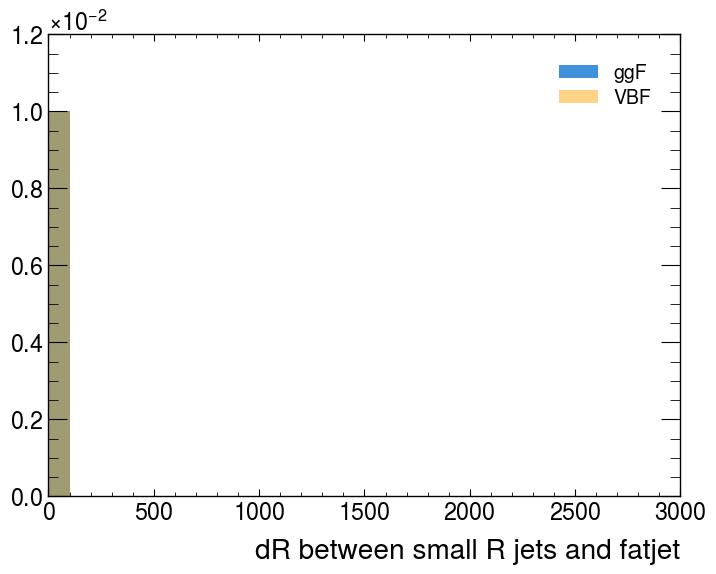

In [77]:
plt.hist(ak.flatten(dR_Jj_list[0][dR_Bj_list[0]>.8], axis=-1), bins=bins, density=True, label='ggF')
plt.hist(ak.flatten(dR_Jj_list[1][dR_Bj_list[1]>.8], axis=-1), bins=bins, density=True, alpha=.5, label='VBF')
plt.legend()
plt.xlabel('dR between small R jets and fatjet')

In [26]:
bins = np.arange(0, 5, .1)
ggF_num, edges = np.histogram(ak.flatten(dR_Jj_list[0][dR_Bj_list[0]>.8], axis=-1), bins=bins)
VBF_num, edges = np.histogram(ak.flatten(dR_Jj_list[1][dR_Bj_list[1]>.8], axis=-1), bins=bins)
plt.stairs(ggF_num*theory_weights[0], edges, label='ggF')
plt.stairs(VBF_num*theory_weights[1], edges, label='VBF')
plt.legend()
plt.xlabel('dR between small R jets and fatjet')
plt.ylabel('# of weighted events')

NameError: name 'dR_Jj_list' is not defined

Text(1, 0, 'dR between small R jets and fatjet')

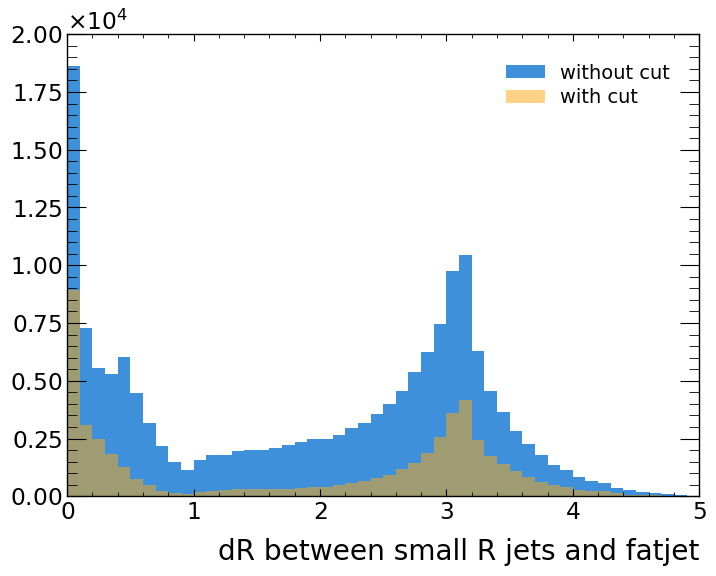

In [571]:
bins = np.arange(0, 5, .1)
plt.hist(ak.flatten(dR_Jj_list[0], axis=-1), bins=bins, label='without cut')
plt.hist(ak.flatten(dR_Jj_list[0][dR_Bj_list[0]>.8], axis=-1), bins=bins, alpha=.5, label='with cut')
plt.legend()
plt.xlabel('dR between small R jets and fatjet')

Text(1, 0, 'mjj')

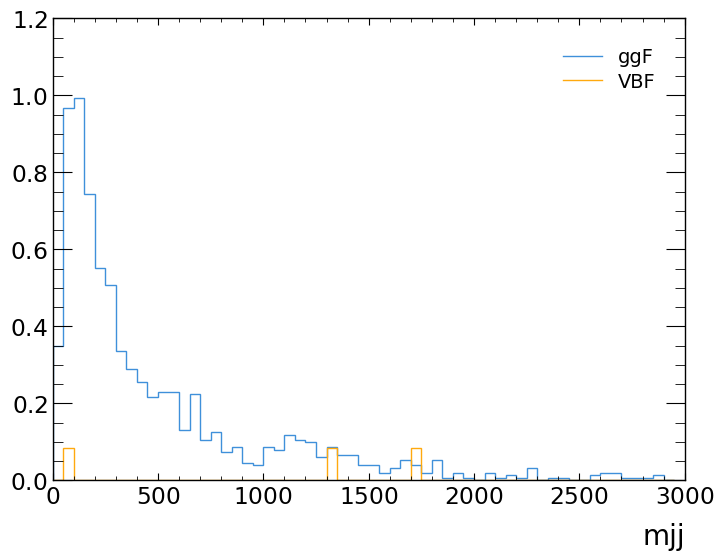

In [699]:
bins = np.arange(0, 3000, 50)

ggF_mjj, edges = np.histogram(ak.flatten(m_jj_list[0][ak.num(dR_jj_list[0][(deta_jj_list[0]>3.5) & (m_jj_list[0]>1000)])>=2], axis=-1), bins=bins)
VBF_mjj, edges = np.histogram(ak.flatten(m_jj_list[1][ak.num(dR_jj_list[1][(deta_jj_list[1]>3.5) & (m_jj_list[1]>1000)])>=2], axis=-1), bins=bins)
plt.stairs(ggF_mjj*theory_weights[0], edges, label='ggF')
plt.stairs(VBF_mjj*theory_weights[1], edges, label='VBF')
plt.legend()
plt.xlabel('mjj')

Text(1, 0, 'mjj')

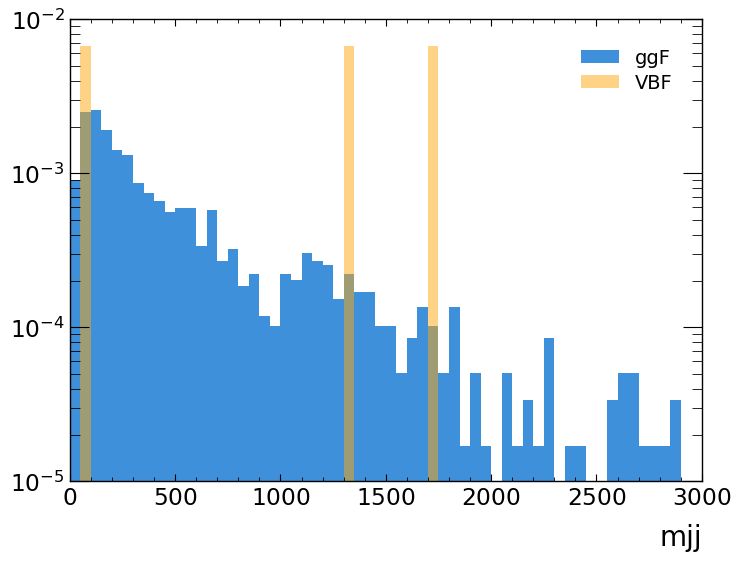

In [700]:
bins = np.arange(0, 3000, 50)
plt.hist(ak.flatten(m_jj_list[0][ak.num(dR_jj_list[0][(deta_jj_list[0]>3.5) & (m_jj_list[0]>1000)])>=2], axis=-1), bins=bins, label='ggF', density=True)
plt.hist(ak.flatten(m_jj_list[1][ak.num(dR_jj_list[1][(deta_jj_list[1]>3.5) & (m_jj_list[1]>1000)])>=2], axis=-1), bins=bins, alpha=.5, label='VBF', density=True)
plt.legend()
plt.yscale('log')
plt.xlabel('mjj')

Text(1, 0, 'mjj')

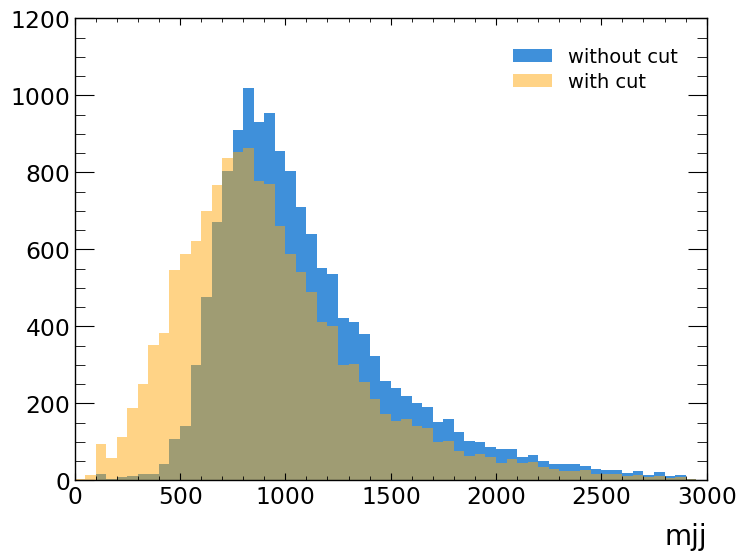

In [576]:
bins = np.arange(0, 3000, 50)
plt.hist(ak.max(m_jj_list[0], axis=-1), bins=bins, label='without cut')
plt.hist(ak.max(m_jj_list[0][dR_Bj_list[0]>.8], axis=-1), bins=bins, alpha=.5, label='with cut')
plt.legend()
plt.xlabel('mjj')

Text(1, 0, '$\\eta_{jj}$')

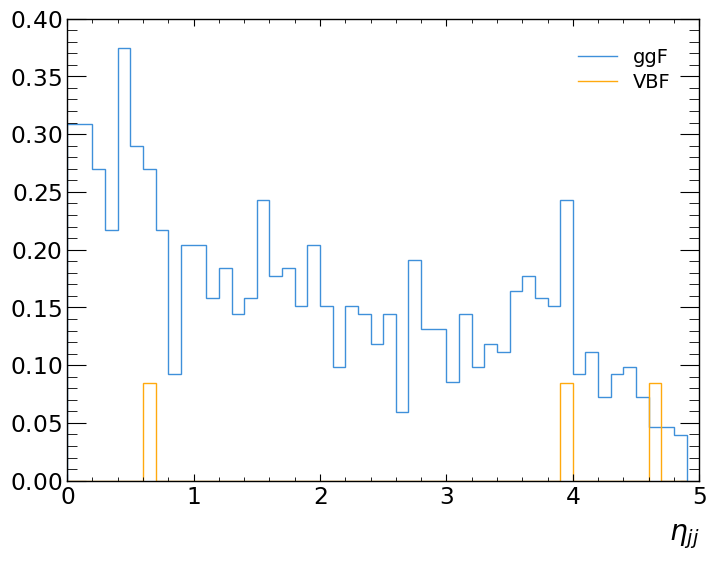

In [701]:
bins = np.arange(0, 5, .1)
ggF_deta_jj, edges = np.histogram(ak.flatten(deta_jj_list[0][ak.num(dR_jj_list[0][(deta_jj_list[0]>3.5) & (m_jj_list[0]>1000)])>=2], axis=-1), bins=bins)
VBF_deta_jj, edges = np.histogram(ak.flatten(deta_jj_list[1][ak.num(dR_jj_list[1][(deta_jj_list[1]>3.5) & (m_jj_list[1]>1000)])>=2], axis=-1), bins=bins)
plt.stairs(ggF_deta_jj*theory_weights[0], edges, label='ggF')
plt.stairs(VBF_deta_jj*theory_weights[1], edges, label='VBF')
plt.legend()
plt.xlabel(r'$\eta_{jj}$')

In [25]:
bins = np.arange(0, 5, .1)
plt.hist(ak.max(deta_jj_list[0][ggF], axis=-1), bins=bins, label='ggF', density=True)
plt.hist(ak.max(deta_jj_list[1][VBF], axis=-1), bins=bins, alpha=.5, label='VBF', density=True)
plt.legend()
plt.xlabel(r'$\eta_{jj}$')

NameError: name 'deta_jj_list' is not defined

Text(1, 0, '$\\eta_{jj}$')

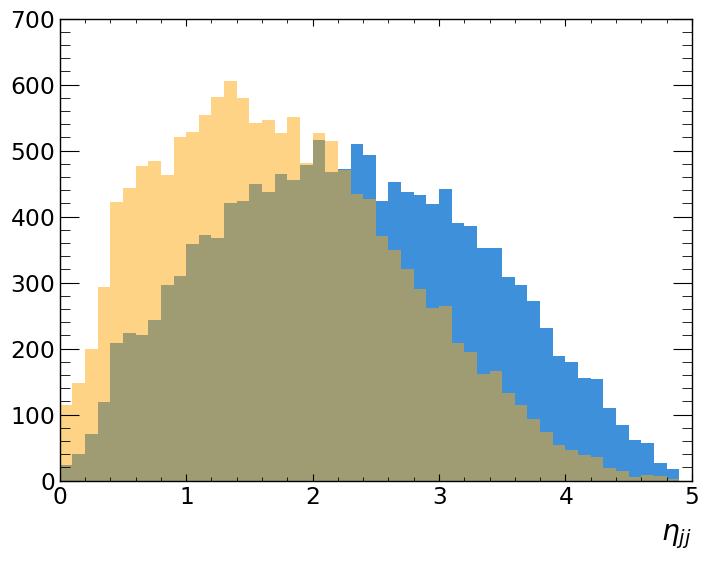

In [579]:
bins = np.arange(0, 5, .1)
plt.hist(ak.max(deta_jj_list[0], axis=-1), bins=bins)
plt.hist(ak.max(deta_jj_list[0][dR_Bj_list[0]>.8], axis=-1), bins=bins, alpha=.5)

plt.xlabel(r'$\eta_{jj}$')

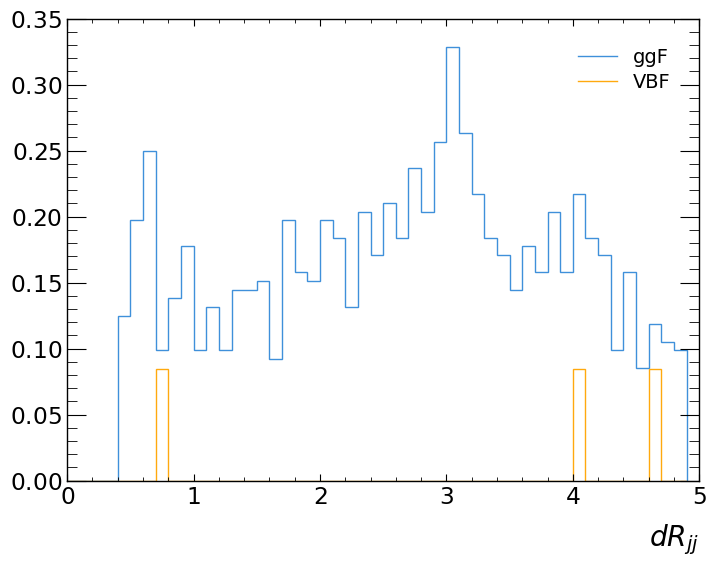

In [706]:
bins = np.arange(0, 5, .1)
ggF_dRjj, edges = np.histogram(ak.flatten(dR_jj_list[0][ggF], axis=-1), bins=bins)
VBF_dRjj, edges = np.histogram(ak.flatten(dR_jj_list[1][VBF], axis=-1), bins=bins)
plt.stairs(ggF_dRjj*theory_weights[0], edges, label='ggF')
plt.stairs(VBF_dRjj*theory_weights[1], edges, label='VBF')

plt.xlabel(r'$dR_{jj}$')
plt.legend()

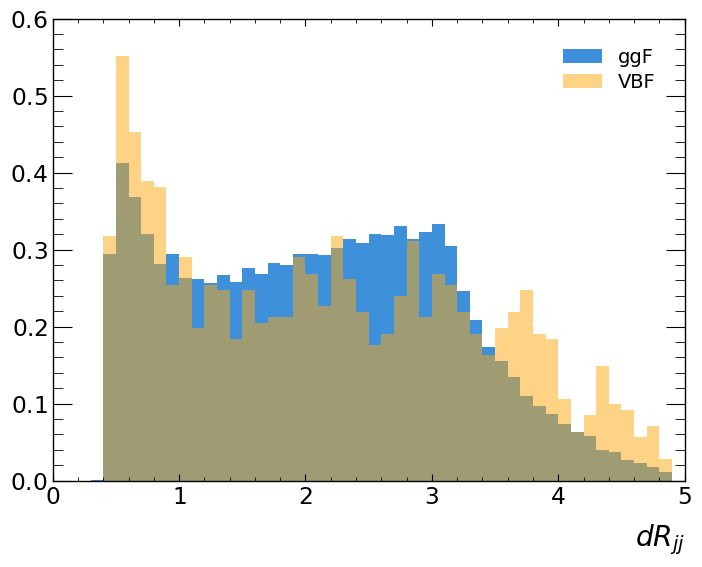

In [691]:
bins = np.arange(0, 5, .1)
plt.hist(ak.flatten(dR_jj_list[0], axis=-1), bins=bins, label='ggF', density=True)
plt.hist(ak.flatten(dR_jj_list[1], axis=-1), bins=bins, alpha=.5, label='VBF', density=True)
plt.xlabel(r'$dR_{jj}$')
plt.legend()

In [137]:

a = deta_jj[deta_jj>3.5]
b=ak.num(a)>1
a[b]

<Array [[4.2, 3.74, 3.9, 3.87], ..., [3.8, ...]] type='1036 * var * float32'>

CPU times: user 5.83 s, sys: 3.85 ms, total: 5.83 s
Wall time: 5.86 s


Text(0.5, 0, '$\\Delta R$ between ggF fatjet and boson')

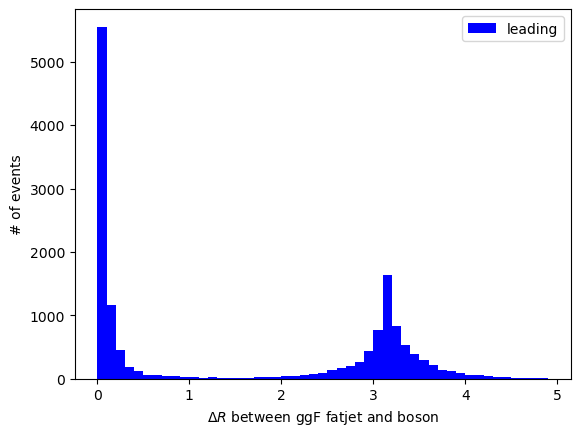

In [18]:
%%time
boson_vec4_leading = boson_vec4[:,0]
fatjet_vec4_leading = fatjet_vec4[:,0]
dRL = [boson_vec4_leading[i].delta_r(fatjet_vec4_leading[i]) for i in range(len(ggF_fatjetpt))]
#dRS = [boson_vec4[:,0][i].delta_r(fatjet_vec4[:,1][i]) for i in range(len(ggF_fatjetpt))]
bins= np.arange(0, 5, .1)
num_SRL = plt.hist(dRL, bins=bins, color = 'blue', label='leading')
#num_SRS = plt.hist(dRS, bins=bins, alpha=.5, color = 'orange', label='subleading')
plt.ylabel('# of events')
plt.legend()
plt.xlabel(r'$\Delta R$ between ggF fatjet and boson')

array([    0.,  1069., 11461.,  2013.,   145.])

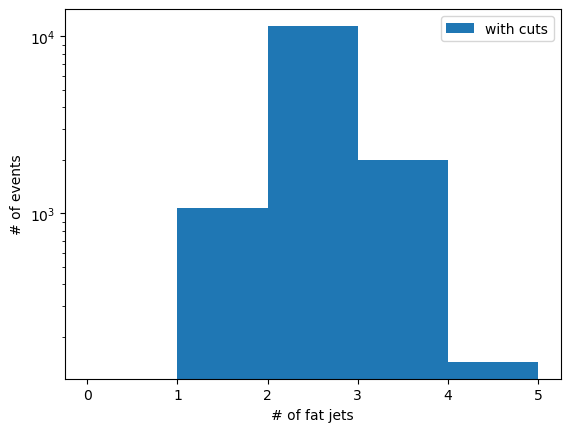

In [94]:

bins=np.arange(0, 6, 1)

num = plt.hist(ak.num(ggF_fatjetpt), bins=bins, label='with cuts')
plt.xlabel('# of fat jets')
plt.ylabel('# of events')
plt.legend()
plt.yscale('log')
num[0]

Text(0, 0.5, '# of events')

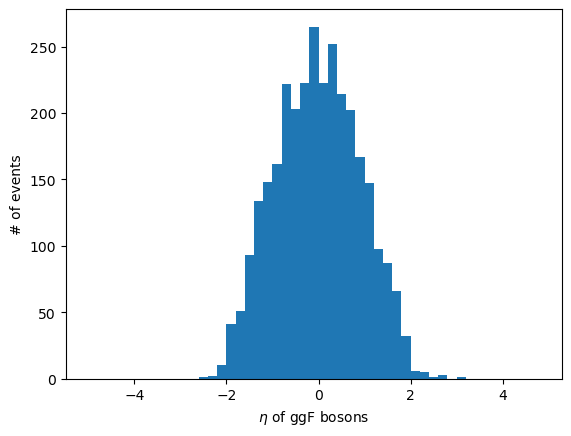

In [31]:
ggF_boson_eta = .5*np.log((ggF_bosone+ggF_bosonpz)/((ggF_bosone-ggF_bosonpz)))
#ggF_boson_eta = ggF_boson_eta[ak.num(ggF_boson_eta)>=1]
bins = np.arange(-5, 5, .2)
num = plt.hist(ggF_boson_eta[:, 0], bins=bins)
plt.xlabel(r'$\eta$ of ggF bosons')
plt.ylabel('# of events')

Text(0, 0.5, '# of events')

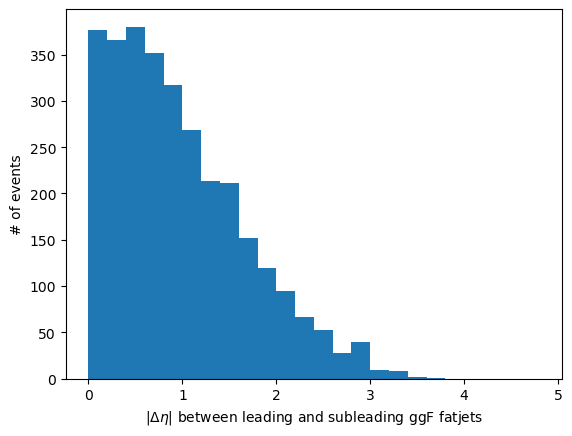

In [32]:
ggF_fatjet_eta = .5*np.log((ggF_fatjete+ggF_fatjetpz)/((ggF_fatjete-ggF_fatjetpz)))
bins = np.arange(0, 5, .2)
num = plt.hist(abs(ggF_fatjet_eta[:, 0]-ggF_fatjet_eta[:,1]), bins=bins)
plt.xlabel(r'|$\Delta\eta$| between leading and subleading ggF fatjets')
plt.ylabel('# of events')

In [46]:
ak.min(ggF_fatjet_phi[:,0]), np.pi/2

(-1.5704061, 1.5707963267948966)

In [47]:
bins=np.arange(-np.pi, np.pi, .1)
ggF_fatjet_phi = np.arctan2(ggF_fatjetpy/ggF_fatjetpx)

num = plt.hist(ggF_fatjet_phi[:,0], bins=bins)

TypeError: arctan2() takes from 2 to 3 positional arguments but 1 were given

Text(0.5, 0, '$\\Delta R$ between ggF fatjet and boson')

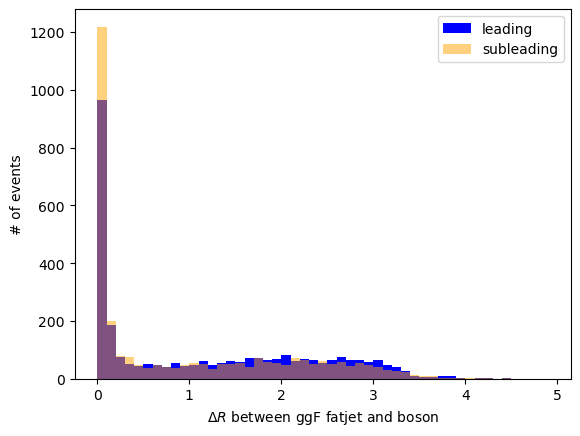

In [33]:
ggF_fatjet_phi = np.arcsin(ggF_fatjetpx/ggF_fatjetpt)
ggF_boson_phi = np.arcsin(ggF_bosonpx/ggF_bosonpt)
ggF_fjphi2 = (ggF_fatjet_phi[:, 0] - ggF_fatjet_phi[:, 1])**2
ggF_fjeta2 = (ggF_fatjet_eta[:, 0] - ggF_fatjet_eta[:, 1])**2
ggF_fj_dR = np.sqrt(ggF_fjphi2+ggF_fjeta2)

ggF_SRL_phi2 = (ggF_fatjet_phi[:, 0] - ggF_boson_phi[:, 0])**2
ggF_SRL_eta2 = (ggF_fatjet_eta[:, 0]-ggF_boson_eta[:,0])**2
ggF_SRL_dR = np.sqrt(ggF_SRL_phi2+ggF_SRL_eta2)
ggF_SRS_phi2 = (ggF_fatjet_phi[:, 1] - ggF_boson_phi[:, 0])**2
ggF_SRS_eta2 = (ggF_fatjet_eta[:, 1]-ggF_boson_eta[:,0])**2
ggF_SRS_dR = np.sqrt(ggF_SRS_phi2+ggF_SRS_eta2)

bins= np.arange(0, 5, .1)
num_SRL = plt.hist(ggF_SRL_dR, bins=bins, color = 'blue', label='leading')
num_SRS = plt.hist(ggF_SRS_dR, bins=bins, alpha=.5, color = 'orange', label='subleading')
plt.ylabel('# of events')
plt.legend()
plt.xlabel(r'$\Delta R$ between ggF fatjet and boson')

In [25]:
sum(num_SRL[0]), sum(num_SRS[0])

(3059.0, 3059.0)

Text(0.5, 0, '$\\Delta R$ between ggF leading and subleading fatjet')

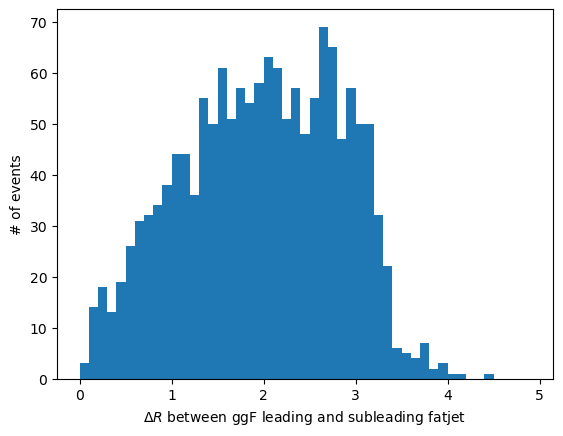

In [274]:
bins= np.arange(0, 5, .1)
num = plt.hist(ggF_fj_dR[ggF_SRS_dR<.3], bins=bins)
plt.ylabel('# of events')
plt.xlabel(r'$\Delta R$ between ggF leading and subleading fatjet')

In [312]:
ggF_H_fj_m

<Array [[121, 91.9], [...], ..., [80.1, 211]] type='1629 * var * float32[pa...'>

Text(0.5, 0, 'mass of ggF Signal Leading fatjet')

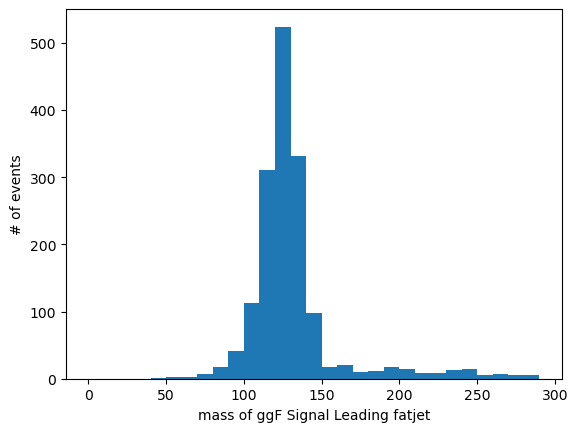

In [334]:
recoil = []
SRL_cut = (ggF_SRL_dR<0.3) & (ggF_fatjetNB[:,0]==2)
ggF_H_fj_pt = ggF_fatjetpt[SRL_cut]
ggF_H_fj_m = ggF_fatjetm[SRL_cut]

ggF_H_fj_pt=ggF_H_fj_pt[ak.num(ggF_H_fj_pt)>0]
ggF_H_fj_m=ggF_H_fj_m[ak.num(ggF_H_fj_m)>0]

mass_bins= np.arange(0, 300, 10)
num = plt.hist((ggF_H_fj_m[:, 0]), bins=mass_bins)
recoil.append(ggF_H_fj_m[:, 1])
plt.ylabel('# of events')
plt.xlabel(r'mass of ggF Signal Leading fatjet')


Text(0.5, 0, 'mass of ggF signal subleading large-R jet')

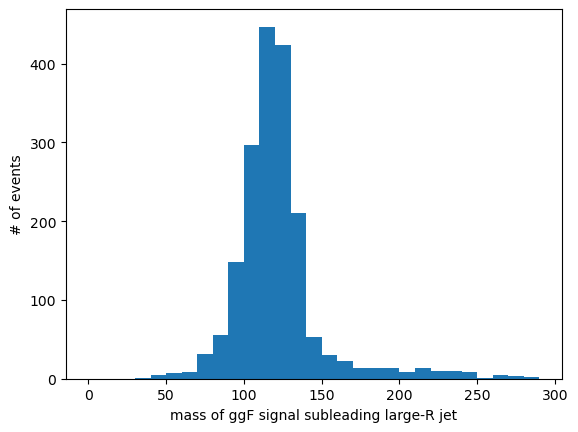

In [335]:
SRS_cut = (ggF_SRS_dR<0.3) & (ggF_fatjetNB[:,1]==2)
ggF_H_fj_pt = ggF_fatjetpt[SRS_cut]
ggF_H_fj_m = ggF_fatjetm[SRS_cut]

ggF_SRS_pt=ggF_H_fj_pt[ak.num(ggF_H_fj_pt)>0]
ggF_SRS_m=ggF_H_fj_m[ak.num(ggF_H_fj_m)>0]

mass_bins= np.arange(0, 300, 10)
num = plt.hist((ggF_SRS_m[:,1]), bins=mass_bins)
recoil.append(ggF_SRS_m[:, 0])
plt.ylabel('# of events')
plt.xlabel(r'mass of ggF signal subleading large-R jet')


Text(0.5, 0, 'mass of ggF recoiling jet')

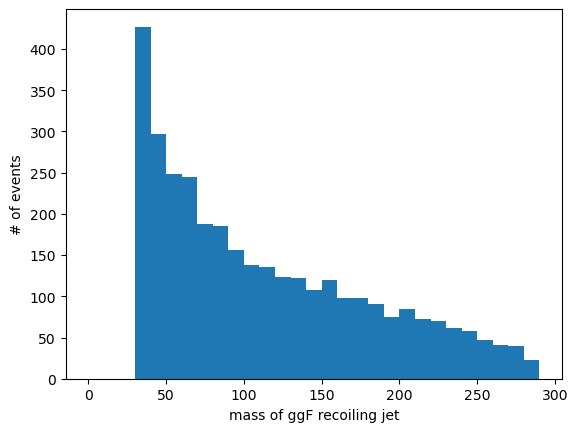

In [337]:
recoil_flat = ak.flatten(recoil)
recoil_cut = (ggF_SRS_dR>0.3)
ggF_recoil_pt = ggF_fatjetpt[recoil_cut]
ggF_recoil_m = ggF_fatjetm[recoil_cut]

#ggF_recoil_pt=ggF_H_fj_pt[ak.num(ggF_recoil_pt)>0]
#ggF_recoil_m=ggF_H_fj_m[ak.num(ggF_recoil_m)>0]

mass_bins= np.arange(0, 300, 10)
num = plt.hist(recoil_flat, bins=mass_bins)
plt.ylabel('# of events')
plt.xlabel(r'mass of ggF recoiling jet')


Text(0.5, 0, 'pt of ggF H candidate fatjet')

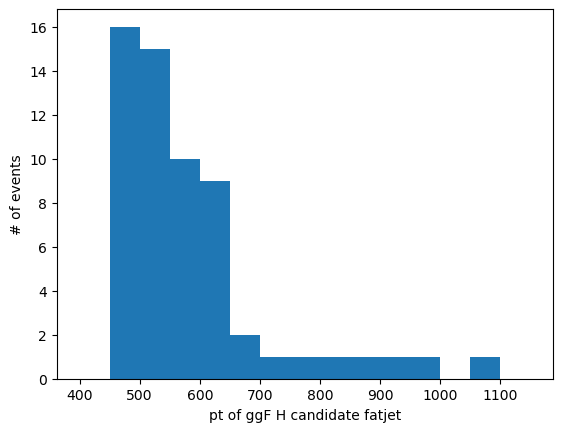

In [211]:
pt_bins= np.arange(400, 1200, 50)
num = plt.hist(ak.flatten(ggF_H_fj_pt), bins=pt_bins)
plt.ylabel('# of events')
plt.xlabel(r'pt of ggF H candidate fatjet')

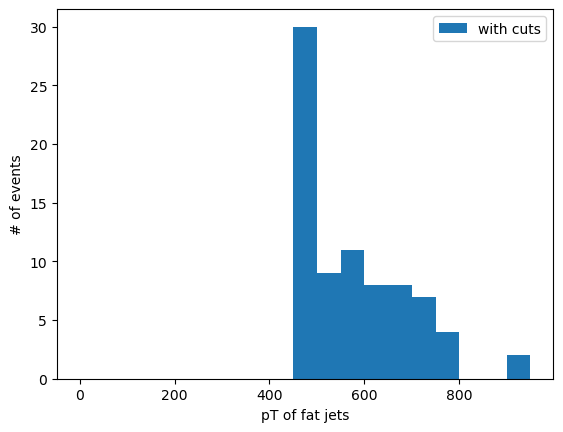

In [24]:
bins = np.arange(0, 1000, 50)
num = plt.hist((VBF_fatjetpt[:,1]), bins=bins, label='with cuts')
plt.xlabel('pT of fat jets')
plt.ylabel('# of events')
plt.legend()

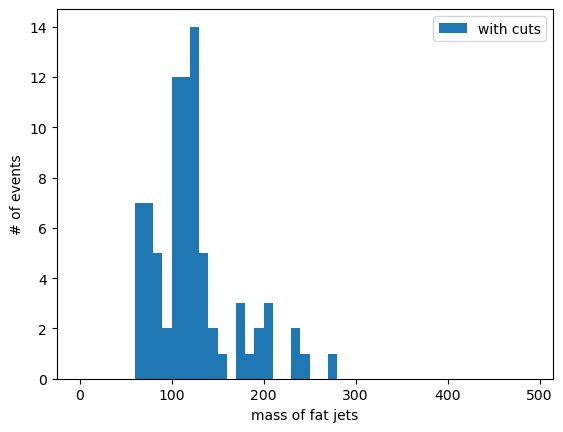

In [16]:
bins = np.arange(0, 500, 10)
num = plt.hist((VBF_fatjetm[:,1]), bins=bins, label='with cuts')
plt.xlabel('mass of fat jets')
plt.ylabel('# of events')
plt.legend()

**Conclusion: minimum of # of fatjet decide the minimum of # of jet. Thus it's possible that jets are inside of fatjet.

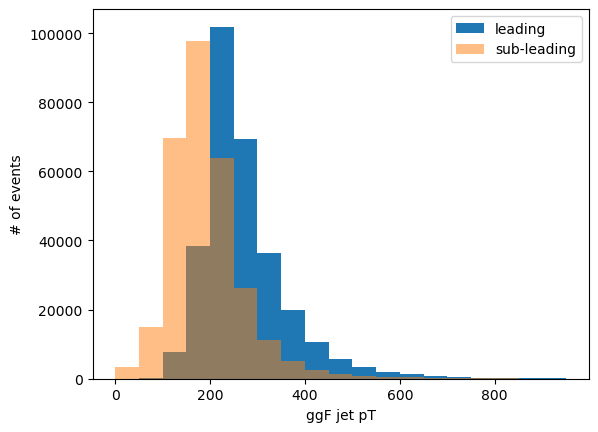

In [42]:
pt_bins = np.arange(0, 1000, 50)
ggF_leading_jet = plt.hist(ggF_jetpt[:,0], bins=pt_bins, label='leading')
ggF_subleading_jet = plt.hist(ggF_jetpt[:,1], alpha=.5, bins=pt_bins, label='sub-leading')
plt.xlabel('ggF jet pT')
plt.ylabel('# of events')
plt.legend()

IndexError: cannot slice ListArray (of length 737) with array(1): index out of range while attempting to get index 1 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-34/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_next_at.cpp#L21)

This error occurred while attempting to slice

    <Array [[349], [357], ..., [526], [313]] type='737 * var * float32[para...'>

with

    (:, 1)

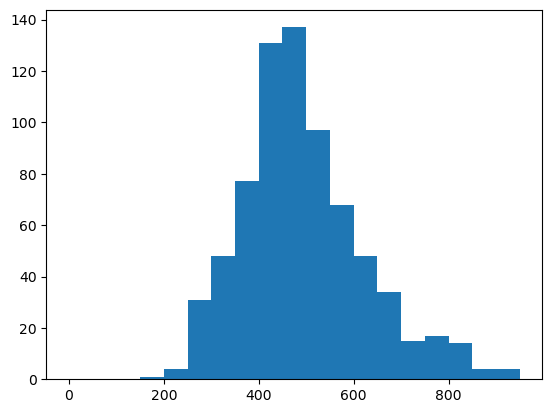

In [37]:
pt_bins = np.arange(0, 1000, 50)
VBF_leading_jet = plt.hist(VBF_jetpt[:,0], bins=pt_bins, label='leading')
VBF_subleading_jet = plt.hist(VBF_jetpt[:,1], alpha=.5, bins=pt_bins, label='sub-leading')
plt.xlabel('VBF jet pT')
plt.ylabel('# of events')
plt.legend()

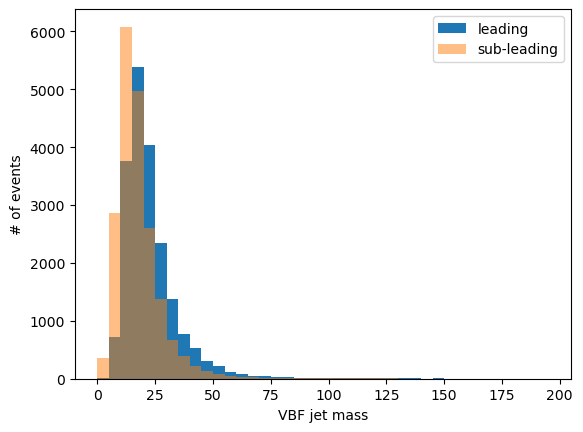

In [354]:
mass_bins = np.arange(0, 200, 5)
VBF_leading_jet = plt.hist(VBF_jetm[:,0], bins=mass_bins, label='leading')
VBF_subleading_jet = plt.hist(VBF_jetm[:,1], alpha=.5, bins=mass_bins, label='sub-leading')
plt.xlabel('VBF jet mass')
plt.ylabel('# of events')
plt.legend()

### selection rules

In [92]:
Nevent=[]
selection = PackedSelection()

fatjet_pt_m_cut = (events.fatJetPt > 450) & (events.fatJetM > 60)
#selection.add("fatjet_pt_m_cut", fatjet_pt_m_cut)

events.fatJetM[fatjet_pt_m_cut].compute()


<Array [[], [], [], [], ..., [], [], [], []] type='362160 * var * float32[p...'>

In [90]:
%%time

Nevents= dask.compute(Nevent)

IndexError: cannot slice ListArray (of length 362160) with array(0): index out of range while attempting to get index 0 (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-34/awkward-cpp/src/cpu-kernels/awkward_ListArray_getitem_next_at.cpp#L21)

This error occurred while attempting to slice

    <Array [[7.93, 45.3, 52.8], ..., [133, ...]] type='362160 * [var * floa...'>

with

    (:, 0)

### How to distinguish between VBF and ggF?
We want to find a certain kinematics that VBF and ggF have different behavior. So far, we look into $|\Delta\eta|$, $\Delta R$, $m_{jj}$ between leading and subleading small-radius jets (antikt4jets) with the cut of requiring the number of fatjet has to be larger than 1.

In [170]:
mjj_list = []
for event in range(len(jetpt)):
    candidate = 0
    event_length = len(jetpt[event])
    for i in range(event_length):
        for j in range(i+1, event_length):
            dE2 = (jete[event, i]+jete[event, j])**2
            dp2 = (jetpx[event, i]+jetpx[event, j])**2 + (jetpy[event, i]+jetpy[event, j])**2 + (jetpz[event, i]+jetpz[event, j])**2
            mjj = np.sqrt(dE2-dp2)
            if candidate < mjj:
                candidate = mjj
    mjj_list.append(candidate)


In [19]:
## Strategy to calculate mjj
# For each event, loop over each event and take any combination of two particles and sum them up
%time
ggF_E = ak.combinations(ggF_jete, 2, axis=-1)
ggF_px = ak.combinations(ggF_jetpx, 2, axis=-1)
ggF_py = ak.combinations(ggF_jetpy, 2, axis=-1)
ggF_pz = ak.combinations(ggF_jetpz, 2, axis=-1)

ggF_mjj_list = []
for i in range(len(ggF_jete)):
    dE2 = (ggF_E[i]["0"]+ggF_E[i]["1"])**2
    p2 = (ggF_px[i]["0"]+ggF_px[i]["1"])**2 + (ggF_py[i]["0"]+ggF_py[i]["1"])**2 + (ggF_pz[i]["0"]+ggF_pz[i]["1"])**2
    mjj = np.sqrt(dE2-p2)
    #print((mjj))
    ggF_mjj_list.append(max(mjj))
#mjj_list

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.68 µs


NameError: name 'ggF_jete' is not defined

Text(0, 0.5, '# of events')

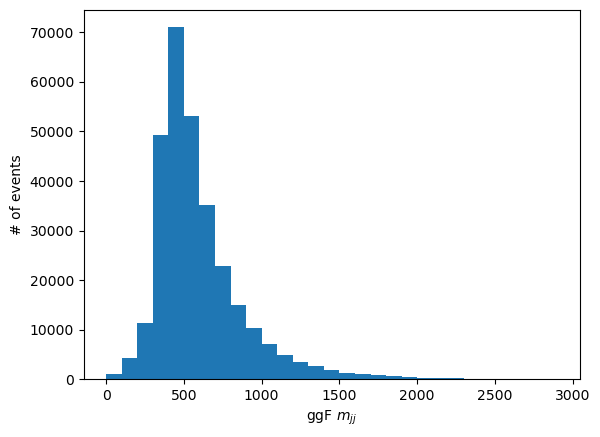

In [299]:
bins = np.arange(0, 3000, 100)
num = plt.hist(ggF_mjj_list, bins=bins)
plt.xlabel('ggF $m_{jj}$')
plt.ylabel('# of events')

In [260]:
## Strategy to calculate mjj
# For each event, loop over each event and take any combination of two particles and sum them up
%%time
VBF_E = ak.combinations(VBF_jete, 2, axis=-1)
VBF_px = ak.combinations(VBF_jetpx, 2, axis=-1)
VBF_py = ak.combinations(VBF_jetpy, 2, axis=-1)
VBF_pz = ak.combinations(VBF_jetpz, 2, axis=-1)

VBF_mjj_list = []
for i in range(len(VBF_jete)):
    dE2 = (VBF_E[i]["0"]+VBF_E[i]["1"])**2
    p2 = (VBF_px[i]["0"]+VBF_px[i]["1"])**2 + (VBF_py[i]["0"]+VBF_py[i]["1"])**2 + (VBF_pz[i]["0"]+VBF_pz[i]["1"])**2
    mjj = np.sqrt(dE2-p2)
    #print((mjj))
    VBF_mjj_list.append(max(mjj))
#mjj_list

Text(0, 0.5, '# of events')

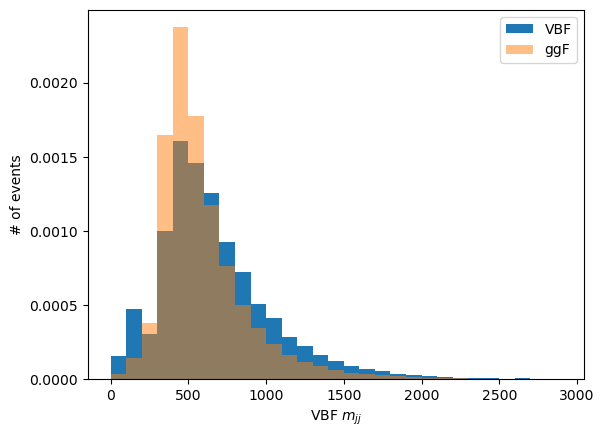

In [301]:
bins = np.arange(0, 3000, 100)
num = plt.hist(VBF_mjj_list, bins=bins, density=True, label='VBF')
num = plt.hist(ggF_mjj_list, bins=bins, alpha=.5, density=True, label='ggF')
plt.legend()
plt.xlabel('VBF $m_{jj}$')
plt.ylabel('# of events')

#### $\eta$ and $m_{jj}$ and $\Delta R$ distribution
$$\eta=\frac{1}{2}ln\frac{|p|+p_z}{|p|-p_z}$$
$$m_{jj}=\sqrt{(E_1+E_2)^2-((p_{x,1}+p_{x,2})^2+(p_{y,1}+p_{y,2})^2+(p_{z,1}+p_{z,2})^2)}$$
$$\Delta R = \sqrt{\Delta\eta^2+\Delta\phi^2}$$

In [29]:
def eta(e, pz):
    return .5*np.log((e+pz)/(e-pz))

Text(0, 0.5, '# of events')

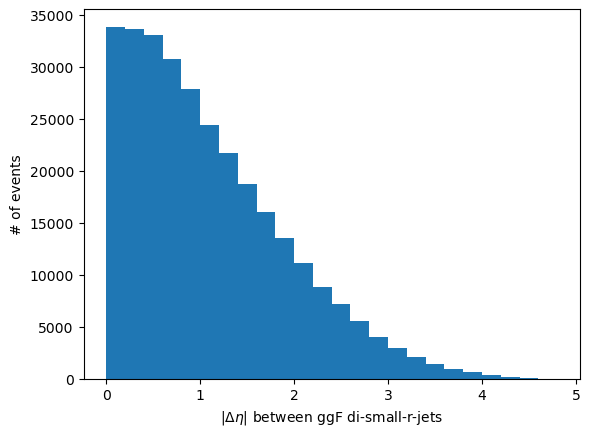

In [294]:
ggF_eta = .5*np.log((ggF_jete+ggF_jetpz)/((ggF_jete-ggF_jetpz)))
bins = np.arange(0, 5, .2)
num = plt.hist(abs(ggF_eta[:, 0]-ggF_eta[:,1]), bins=bins)
plt.xlabel(r'|$\Delta\eta$| between ggF di-small-r-jets')
plt.ylabel('# of events')

Text(0, 0.5, '# of events')

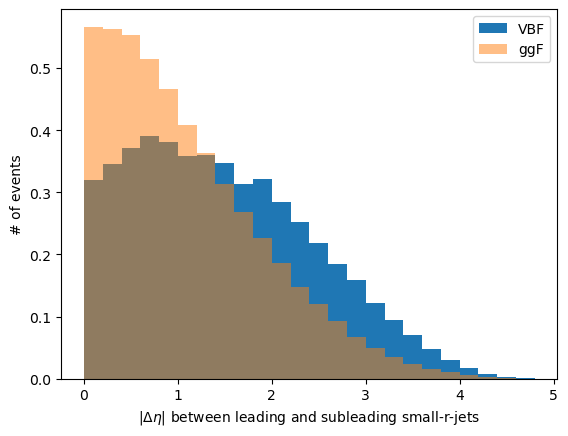

In [317]:
VBF_eta = .5*np.log((VBF_jete+VBF_jetpz)/((VBF_jete-VBF_jetpz)))
bins = np.arange(0, 5, .2)
num = plt.hist(abs(VBF_eta[:, 0]-VBF_eta[:,1]), bins=bins, label='VBF', density=True)
num = plt.hist(abs(ggF_eta[:, 0]-ggF_eta[:,1]), bins=bins, alpha=.5, label='ggF', density=True)
plt.legend()
plt.xlabel(r'|$\Delta\eta$| between leading and subleading small-r-jets')
plt.ylabel('# of events')

Text(0.5, 0, '$\\Delta R$ between ggF di-small-r-jets')

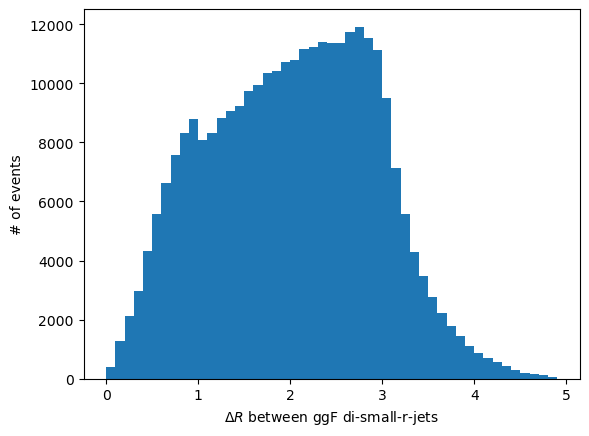

In [298]:
ggF_phi = np.arcsin(ggF_jetpx/ggF_jetpt)
ggF_phi2 = (ggF_phi[:, 0] - ggF_phi[:, 1])**2
ggF_eta2 = (ggF_eta[:, 0]-ggF_eta[:,1])**2
ggF_dR = np.sqrt(ggF_phi2+ggF_eta2)
bins= np.arange(0, 5, .1)
num = plt.hist(ggF_dR, bins=bins)
plt.ylabel('# of events')
plt.xlabel(r'$\Delta R$ between ggF di-small-r-jets')

Text(0.5, 0, '$\\Delta R$ between leading and subleading small-r-jets')

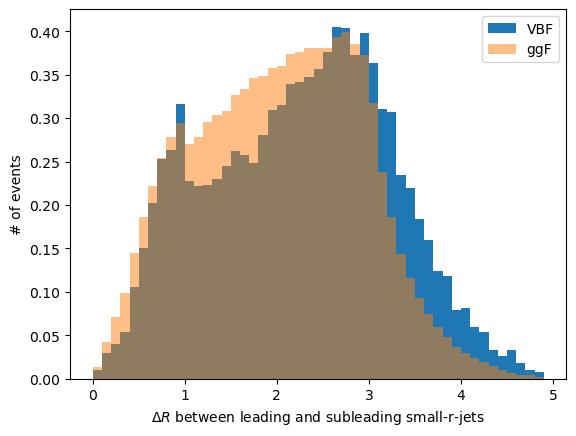

In [315]:
VBF_phi = np.arcsin(VBF_jetpx/VBF_jetpt)
VBF_phi2 = (VBF_phi[:, 0] - VBF_phi[:, 1])**2
VBF_eta2 = (VBF_eta[:, 0]-VBF_eta[:,1])**2
VBF_dR = np.sqrt(VBF_phi2+VBF_eta2)
bins= np.arange(0, 5, .1)
num = plt.hist(VBF_dR, bins=bins, label='VBF', density=True)
num = plt.hist(ggF_dR, bins=bins, alpha=.5, label='ggF', density=True)
plt.legend()
plt.ylabel('# of events')
plt.xlabel(r'$\Delta R$ between leading and subleading small-r-jets')

Text(0, 0.5, '# of events')

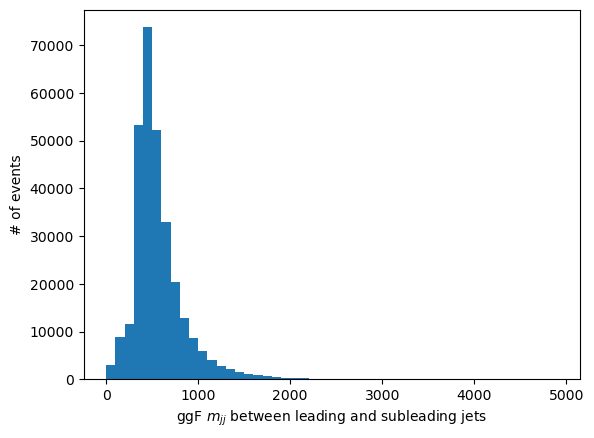

In [304]:
ggF_dE2 = (ggF_jete[:, 0]+ggF_jete[:, 1])**2
ggF_dp2 = (ggF_jetpx[:, 0]+ggF_jetpx[:, 1])**2 + (ggF_jetpy[:, 0]+ggF_jetpy[:, 1])**2 + (ggF_jetpz[:, 0]+ggF_jetpz[:, 1])**2
ggF_m = np.sqrt(ggF_dE2-ggF_dp2)
bins = np.arange(0, 3000, 100)
num = plt.hist(ggF_m, bins=bins)
plt.xlabel('ggF $m_{jj}$ between leading and subleading jets')
plt.ylabel('# of events')
#plt.yscale('log')

Text(0, 0.5, '# of events')

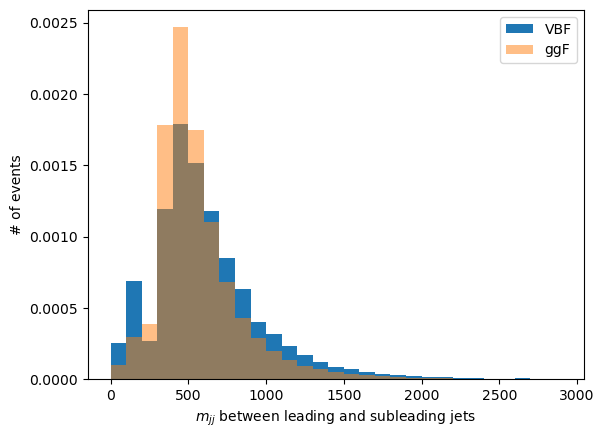

In [316]:
VBF_dE2 = (VBF_jete[:, 0]+VBF_jete[:, 1])**2
VBF_dp2 = (VBF_jetpx[:, 0]+VBF_jetpx[:, 1])**2 + (VBF_jetpy[:, 0]+VBF_jetpy[:, 1])**2 + (VBF_jetpz[:, 0]+VBF_jetpz[:, 1])**2
VBF_m = np.sqrt(VBF_dE2-VBF_dp2)
bins = np.arange(0, 3000, 100)
num = plt.hist(VBF_m, bins=bins, label='VBF', density=True)
num = plt.hist(ggF_m, bins=bins, alpha=.5, label='ggF', density=True)
plt.legend()
plt.xlabel('$m_{jj}$ between leading and subleading jets')
plt.ylabel('# of events')
#plt.yscale('log')


<Array [[247, 226], [327], ..., [204], [325]] type='30326 * [var * float32[...'>

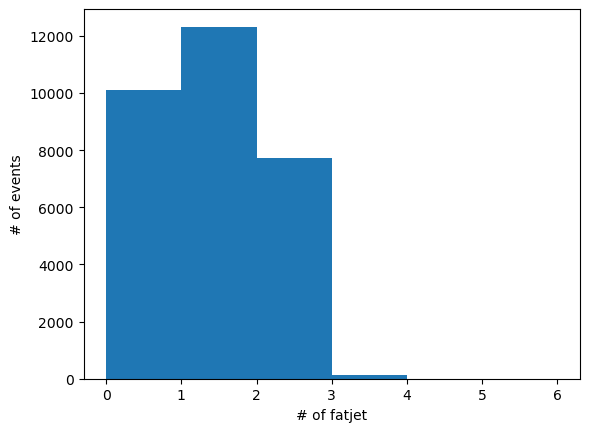

In [35]:
fatjetpt = events.fatJetPt.compute()
fatjetpt2 = fatjetpt[ak.num(fatjetpt)==2]
bins = np.arange(0, 7, 1)
num = plt.hist(ak.num(fatjetpt), bins=bins)
plt.xlabel('# of fatjet')
plt.ylabel('# of events')
fatjetpt0 = fatjetpt[ak.num(fatjetpt)==0]
fatjetpt

### Uproot method

In [214]:
import uproot
VBF_uproot_file = uproot.open(VBF_path)
tree = VBF_uproot_file['evttree']

branch_filter={
        'bosonPdgId', 'bosonStatus', 'bosonBarcode',
 'bosonPt', 'bosonPx', 'bosonPy', 'bosonPz', 'bosonE', 'bosonM',
 'bosonChildPdgId', 'bosonChildPt', 'bosonChildPx', 'bosonChildPy', 'bosonChildPz', 'bosonChildE',
 'jetFlavour', 'jetPt', 'jetPx','jetPy','jetPz','jetE','jetM', 
 'fatJetTruthPt','fatJetTruthPx','fatJetTruthPy','fatJetTruthPz','fatJetTruthE','fatJetTruthM',
 'fatJetRawPt','fatJetRawPx','fatJetRawPy','fatJetRawPz','fatJetRawE','fatJetRawM',
 'fatJetPt','fatJetPx','fatJetPy','fatJetPz','fatJetE','fatJetM',
 'fatJetDiVRJetMass', 'fatJetDiVRJetPt',
 'fatJetTruthLabel',
 'fatJetNBHadrons', 'fatJetNCHadrons',
 'fatJetGN2XHbb', 'fatJetGN2XHcc', 'fatJetGN2XTop', 'fatJetGN2XQCD',
 'fatJetGN2Xv01Hbb','fatJetGN2Xv01Hcc', 'fatJetGN2Xv01Top', 'fatJetGN2Xv01QCD',
 'fatJetGN2Xv02Hbb', 'fatJetGN2Xv02Hcc', 'fatJetGN2Xv02Top', 'fatJetGN2Xv02QCD',
 'fatJetGN2XMHbb',
 'fatJetGN2XMHcc',
 'fatJetGN2XMTop',
 'fatJetGN2XMQCD','eventMCWeight'
}

for event, report in tree.iterate(
    library="ak",
    step_size=50000,
    filter_name=branch_filter,
    report=True,
):
    fatjet_pt_m = (event.fatJetPt>450) & (event.fatJetM>60)
    selected_event = event.fatJetE[fatjet_pt_m]
    print(selected_event)

[[], [], [], [], [], [], [], [], [], ..., [], [], [], [], [], [], [], [], []]


In [217]:
import ROOT
from tqdm import tqdm_notebook
file = TFile(VBF_path)
tree = file.Get('evttree')

for entry in tqdm_notebook(tree, total=tree.GetEntries(), 
                         desc="Processing records"):
    if (len(tree.fatJetPt) >= 2) & (len(tree.bosonPt) > 0):
        if (tree.fatJetPt[0] > 450) & (tree.fatJetM[0]>60):
            print('i')

ModuleNotFoundError: No module named 'ROOT'